# Multi-Proxy Paleoclimate Time-Series Analysis and PCA
### A Pedagogical Reference Notebook — v1.0

Companion to: `REDFIT_WWZ_Reference.ipynb`

### What this notebook does
This notebook extracts the maximum climatic information from raw, multivariate proxy data. It performs descriptive statistics, rigorous correlation analysis (accounting for autocorrelation), and reduces dimensionality using PCA and alternative methods (Factor Analysis, ICA, UMAP). The final distilled climate signals (PC scores) are exported to a CSV file ready for spectral analysis in REDFIT.

### How to use this notebook
1. Run cells sequentially from top to bottom.
2. **Only edit code inside cells marked with `USER INPUT BLOCK`.**
3. Review the outputs and Markdown theory blocks to ensure your choices are scientifically sound.

### What you need
- A raw dataset in `.xlsx` or `.csv` format containing an age column and multiple proxy columns.
- Approximately 30 minutes to review the outputs.

---
## Theory: Why Multivariate Analysis?

A single paleoclimate proxy (e.g., foram abundance, δ¹⁸O, or an XRF element ratio) rarely represents a pure, isolated climatic variable. Instead, each proxy is a **linear mixture** of overlapping signals: temperature, ice volume, local salinity, preservation, and ecological noise.

By analyzing multiple complementary proxies together, we can mathematically separate the shared, overarching climatic signals from the unique noise of individual proxies. 

The fundamental question this notebook answers is: **"What are the independent dimensions of climatic variance encoded in my multi-proxy dataset, and what is the trajectory of the dominant climate state over time?"**

---
## Library Overview

| Library | Role |
|---|---|
| `pandas` | Data loading and manipulation |
| `numpy` | Numerical computation |
| `matplotlib` | All plotting and visualization |
| `scipy` | Correlation tests, statistical distributions, transformations |
| `sklearn` | PCA and all alternative dimensionality reduction |
| `statsmodels` | ADF/KPSS stationarity tests |

*Note: If you receive a `ModuleNotFoundError` for `statsmodels`, install it via your Anaconda prompt:*
`conda install statsmodels`

In [18]:
# IMPORTS AND ENVIRONMENT CHECK (do not edit)
# ============================================================
import sys
import warnings
warnings.filterwarnings('ignore')  # Suppress complex-warning spam from ICA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import scipy
from scipy import stats
from scipy.signal import correlate, butter, filtfilt
import sklearn
from sklearn.decomposition import PCA, FactorAnalysis, FastICA
from sklearn.preprocessing import StandardScaler
import datetime, json, os

# Try importing statsmodels gracefully
try:
    import statsmodels
    import statsmodels.tsa.stattools as sm_tsa
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("WARNING: 'statsmodels' not found. Stationarity tests (ADF/KPSS) will be skipped.")
    print("To install: conda install statsmodels")

# Try importing UMAP gracefully
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("WARNING: 'umap-learn' not found. UMAP visualization will be skipped.")
    print("To install: conda install -c conda-forge umap-learn")

print("="*60)
print("  ENVIRONMENT CHECK")
print("="*60)
for name, ver in [
    ("numpy",        np.__version__),
    ("pandas",       pd.__version__),
    ("matplotlib",   plt.matplotlib.__version__),
    ("scipy",        scipy.__version__),
    ("scikit-learn", sklearn.__version__),
    ("statsmodels",  statsmodels.__version__ if HAS_STATSMODELS else "NOT FOUND"),
    ("umap-learn",   umap.__version__ if HAS_UMAP else "NOT FOUND"),
]:
    print(f"{name:<15} : {ver}")

To install: conda install -c conda-forge umap-learn
  ENVIRONMENT CHECK
numpy           : 1.26.4
pandas          : 3.0.5
matplotlib      : 3.11.1
scipy           : 1.15.3
scikit-learn    : 1.9.0
statsmodels     : 0.14.6
umap-learn      : NOT FOUND


---
## Section 1 · Data Loading

This notebook supports both `.xlsx` and `.csv` files.
- The file must contain a numeric Age/Time column.
- The proxy columns do NOT need to have the exact same temporal coverage. Missing data (NaNs) are handled carefully column-by-column in the statistics, and via user-defined strategies during PCA.

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║          USER INPUT BLOCK 1 — Data File                     ║
# ╚══════════════════════════════════════════════════════════════╝

DATA_FILE  = "15ka.xlsx"   # Relative path to your data file
SHEET_NAME = 0                   # 0 = first sheet, or use the sheet name as a string (e.g., 'Data')

In [20]:
# FILE LOADING (do not edit)
# ============================================================
print(f"Loading data from: {DATA_FILE} ...")

if DATA_FILE.lower().endswith('.csv'):
    raw_df = pd.read_csv(DATA_FILE)
elif DATA_FILE.lower().endswith('.xlsx') or DATA_FILE.lower().endswith('.xls'):
    raw_df = pd.read_excel(DATA_FILE, sheet_name=SHEET_NAME)
else:
    raise ValueError("File must be .csv or .xlsx")

print("="*60)
print(f"  FILE LOADED SUCESSFULLY")
print("="*60)
print(f"  Total rows    : {len(raw_df)}")
print(f"  Total columns : {len(raw_df.columns)}\n")

print("  COLUMN INVENTORY:")
print(f"  {'Column Name':<25} | {'Type':<10} | {'Non-Null Count'}")
print("  " + "-"*55)
for col in raw_df.columns:
    print(f"  {str(col):<25} | {str(raw_df[col].dtype):<10} | {raw_df[col].count()}")

print("\n  FIRST 5 ROWS:")
display(raw_df.head())

Loading data from: 15ka.xlsx ...
  FILE LOADED SUCESSFULLY
  Total rows    : 85
  Total columns : 21

  COLUMN INVENTORY:
  Column Name               | Type       | Non-Null Count
  -------------------------------------------------------
  Age Ka                    | float64    | 85
  % N. dutertrei            | float64    | 85
  % siphonifera             | float64    | 85
  % obliquiloculata         | float64    | 85
  % venezulana              | float64    | 85
  % glutinata               | float64    | 85
  % bulloides               | float64    | 85
  % ruber                   | float64    | 85
  % universa                | float64    | 85
  % sacculifer              | float64    | 85
  % menardii                | float64    | 85
  % susceptible species     | float64    | 85
  G.bulloides/G. ruber      | float64    | 85
  fertile species           | float64    | 85
  Unnamed: 14               | float64    | 0
  Age Ka.1                  | float64    | 85
  % N. dutertrei.1         

,Age Ka,% N. dutertrei,% siphonifera,% obliquiloculata,% venezulana,% glutinata,% bulloides,% ruber,% universa,% sacculifer,...,% susceptible species,G.bulloides/G. ruber,fertile species,Unnamed: 14,Age Ka.1,% N. dutertrei.1,% obliquiloculata.1,% venezulana.1,% menardii.1,Resistant species
0,1.747000,16.888889,12.444444,1.777778,9.333333,0.444444,0.444444,2.222222,4.000000,1.777778,...,8.000000,0.200000,0.888889,NaN,1.747000,16.888889,1.777778,9.333333,6.666667,34.666667
1,1.990698,12.851406,10.441767,0.401606,7.630522,0.401606,1.204819,2.222222,0.444444,6.222222,...,8.032129,0.542169,1.606426,NaN,1.990698,12.851406,0.401606,7.630522,11.111111,31.994645
2,2.234395,26.315789,27.751196,1.435407,7.177033,2.392344,0.478469,1.333333,3.555556,3.555556,...,9.090909,0.358852,2.870813,NaN,2.234395,26.315789,1.435407,7.177033,7.555556,42.483785
3,2.478093,14.545455,11.363636,1.818182,8.636364,1.818182,0.909091,2.666667,2.222222,4.444444,...,9.545455,0.340909,2.727273,NaN,2.478093,14.545455,1.818182,8.636364,15.111111,40.111111
4,2.721791,12.295082,12.295082,1.639344,9.016393,1.229508,0.819672,1.777778,1.333333,5.333333,...,7.786885,0.461066,2.049180,NaN,2.721791,12.295082,1.639344,9.016393,12.000000,34.950820


---
## Selecting Columns & Climatic Intervals

**Age Column:** Must be numeric (ka, yr BP, or Ma). The notebook handles both increasing and decreasing time conventions.
**Proxy Columns:** Any numeric column representing a measurable property you want to feed into the PCA.

**Climatic Intervals:**
You can define well-known time intervals (like the Younger Dryas or LGM) in a dictionary below. The dashboard plots will automatically overlay faint shaded horizontal bands corresponding to these intervals if they fall within your data's age range. This provides excellent visual context.

In [23]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   USER INPUT BLOCK 2 — Columns & Climatic Intervals         ║
# ╚══════════════════════════════════════════════════════════════╝

AGE_COLUMN    = 'Age Ka'            # The name of your time/age column
AGE_DIRECTION = 'oldest_right'   # 'oldest_right' (ka BP, older values are numerically larger)
                                 # 'oldest_left' (yr CE, older values are numerically smaller)

PROXY_COLUMNS = [
    # List the exact names of the proxy columns to analyze
    '% N. dutertrei', 
    '% obliquiloculata',
    '% siphonifera',
    '% venezulana',
    '% glutinata',
    '% bulloides',
    '% ruber',
    '% universa',
    '% sacculifer',
    '% menardii'
]

# (Optional) Used for axis labels. Leave {} if unknown.
PROXY_UNITS = {                   
    'N. dutertrei': '%',
    'obliquiloculata': '%',
    'siphonifera': '%',
    'venezulana': '%',
    'glutinata': '%',
    'bulloides': '%',
    'ruber': '%',
    'universa': '%',
    'sacculiferi': '%',
    '% menardii': '‰'
}

# (Optional) Define well-known climatic intervals for shading on plots.
# Format: 'Name': [start_age, end_age] (in the same units as AGE_COLUMN)
CLIMATIC_INTERVALS = {
    'Late Holocene': [0, 4.2],
    'Mid Holocene': [4.2, 8.2],
    'Early Holocene': [8.2, 11.7],
    'Younger Dryas (YD)': [11.7, 12.9],
    'Bølling-Allerød (B/A)': [12.9, 14.7],
    'Heinrich Stadial 1 (HS1)': [14.7, 18.0],
    'LGM': [19.0, 23.0]
}

In [24]:
# DATA PARSING AND VALIDATION (do not edit)
# ============================================================

# 1. Clean missing age rows
df_clean = raw_df.dropna(subset=[AGE_COLUMN]).copy()
for col in [AGE_COLUMN] + PROXY_COLUMNS:
    if col not in df_clean.columns:
        raise ValueError(f"Column '{col}' not found in data.")
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 2. Sort chronologically
df_clean = df_clean.sort_values(by=AGE_COLUMN, ascending=(AGE_DIRECTION == 'oldest_left'))
global_time = df_clean[AGE_COLUMN].values
global_df = df_clean.copy()

global_proxy_dict = {}
for col in PROXY_COLUMNS:
    global_proxy_dict[col] = df_clean[col].values

# 3. Calculate Global Intersection
mask = np.ones(len(global_time), dtype=bool)
for col in PROXY_COLUMNS:
    mask = mask & ~np.isnan(global_proxy_dict[col])
intersection_count = mask.sum()
total_count = len(global_time)
drop_pct = (1.0 - intersection_count / total_count) * 100

print("="*60)
print(f"  DATA MATRIX REPORT")
print("="*60)
print(f"  Total valid age points : {total_count}")
print(f"  Age span               : {np.nanmin(global_time):.3f} to {np.nanmax(global_time):.3f}")
print(f"  Total proxies selected : {len(PROXY_COLUMNS)}\n")

print("  TEMPORAL COVERAGE:")
for col in PROXY_COLUMNS:
    v = global_proxy_dict[col]
    valid_mask = ~np.isnan(v)
    count = valid_mask.sum()
    if count == 0:
        print(f"    {col:<20}: EMPTY!")
    else:
        t_min, t_max = np.min(global_time[valid_mask]), np.max(global_time[valid_mask])
        print(f"    {col:<20}: {count:>4} pts | {t_min:.2f} to {t_max:.2f}")

print("\n  GLOBAL INTERSECTION (Points where ALL proxies are present):")
print(f"    Intersection points  : {intersection_count} / {total_count} ({100 - drop_pct:.1f}% retention)")

if drop_pct > 30:
    print("\n  [WARNING] ──────────────────────────────────────────────────────────")
    print(f"  Intersection drops {drop_pct:.1f}% of your data points!")
    print("  When you run PCA, using HANDLE_MISSING='intersection' will severely")
    print("  truncate your record. Strongly consider using 'impute_mean' instead.")
    print("  ────────────────────────────────────────────────────────────────────")

  DATA MATRIX REPORT
  Total valid age points : 85
  Age span               : 1.747 to 15.195
  Total proxies selected : 10

  TEMPORAL COVERAGE:
    % N. dutertrei      :   85 pts | 1.75 to 15.20
    % obliquiloculata   :   85 pts | 1.75 to 15.20
    % siphonifera       :   85 pts | 1.75 to 15.20
    % venezulana        :   85 pts | 1.75 to 15.20
    % glutinata         :   85 pts | 1.75 to 15.20
    % bulloides         :   85 pts | 1.75 to 15.20
    % ruber             :   85 pts | 1.75 to 15.20
    % universa          :   85 pts | 1.75 to 15.20
    % sacculifer        :   85 pts | 1.75 to 15.20
    % menardii          :   85 pts | 1.75 to 15.20

  GLOBAL INTERSECTION (Points where ALL proxies are present):
    Intersection points  : 85 / 85 (100.0% retention)


---
## Section 2 · Individual Proxy Statistics

Before combining proxies, we must understand them individually.

- **Mean/Median:** Central tendency. For highly skewed data (e.g., rare foram species %), the median is more robust.
- **Std/CV:** Spread. The Coefficient of Variation (CV = std/mean × 100) allows you to compare the relative variability of proxies measured in completely different units.
- **Skewness:** > 0 indicates a right tail (rare high values). Skewness > 1 suggests a transformation (like `log1p` or `yeo-johnson`) may be mathematically required before PCA.
- **Kurtosis:** > 3 indicates heavy tails (prone to outliers).

In [25]:
# PROXY STATISTICS (do not edit)
# ============================================================

stats_list = []
for col in PROXY_COLUMNS:
    v = global_proxy_dict[col]
    v_valid = v[~np.isnan(v)]
    if len(v_valid) == 0: continue
    
    mean = np.mean(v_valid)
    std = np.std(v_valid, ddof=1)
    
    stats_list.append({
        'Proxy': col,
        'N Valid': len(v_valid),
        'Missing %': f"{(1 - len(v_valid)/len(global_time))*100:.1f}%",
        'Mean': mean,
        'Median': np.median(v_valid),
        'Min': np.min(v_valid),
        'Max': np.max(v_valid),
        'Std Dev': std,
        'CV (%)': (std / np.abs(mean) * 100) if mean != 0 else np.nan,
        'Skewness': stats.skew(v_valid),
        'Kurtosis': stats.kurtosis(v_valid)
    })

stats_df = pd.DataFrame(stats_list).set_index('Proxy')

# Format the dataframe with a gradient to highlight highly skewed or highly variable proxies
styled_stats = stats_df.style.background_gradient(subset=['Skewness'], cmap='OrRd', vmin=0, vmax=2) \
                       .background_gradient(subset=['CV (%)'], cmap='Blues') \
                       .format(precision=2) \
                       .set_caption("Descriptive Statistics per Proxy")

display(styled_stats)

,N Valid,Missing %,Mean,Median,Min,Max,Std Dev,CV (%),Skewness,Kurtosis
Proxy,,,,,,,,,,
% N. dutertrei,85,0.0%,16.01,16.27,2.43,35.93,6.51,40.68,0.42,0.16
% obliquiloculata,85,0.0%,4.44,4.22,0.40,13.17,2.26,50.95,0.88,1.53
% siphonifera,85,0.0%,10.44,9.12,0.59,27.75,5.90,56.56,0.70,-0.15
% venezulana,85,0.0%,3.89,3.38,0.00,9.33,2.65,68.00,0.44,-1.00
% glutinata,85,0.0%,3.18,2.05,0.28,12.96,2.88,90.52,1.48,1.91
% bulloides,85,0.0%,1.35,0.89,0.00,8.64,1.34,99.25,2.61,9.34
% ruber,85,0.0%,12.14,10.67,0.44,32.44,9.27,76.33,0.37,-1.09
% universa,85,0.0%,1.35,1.33,0.00,6.22,1.02,75.82,1.62,4.99
% sacculifer,85,0.0%,9.09,8.44,1.33,25.78,5.05,55.49,0.80,0.55


---
## Section 3 · Multi-Proxy Dashboard

Visualizing covariation is the most important step in time-series analysis. 

- **Vertical Age Axis:** Age is plotted on the Y-axis (descending), visually mirroring the physical depth of a sediment core.
- **Horizontal Proxy Axes:** The proxies are plotted horizontally side-by-side. 
- **Sample Ticks:** A red triangle on the left axis marks each actual sample point.
- **Climatic Intervals:** The shaded horizontal bands highlight the standard climatic intervals defined in User Input Block 2 (e.g., LGM, Younger Dryas).

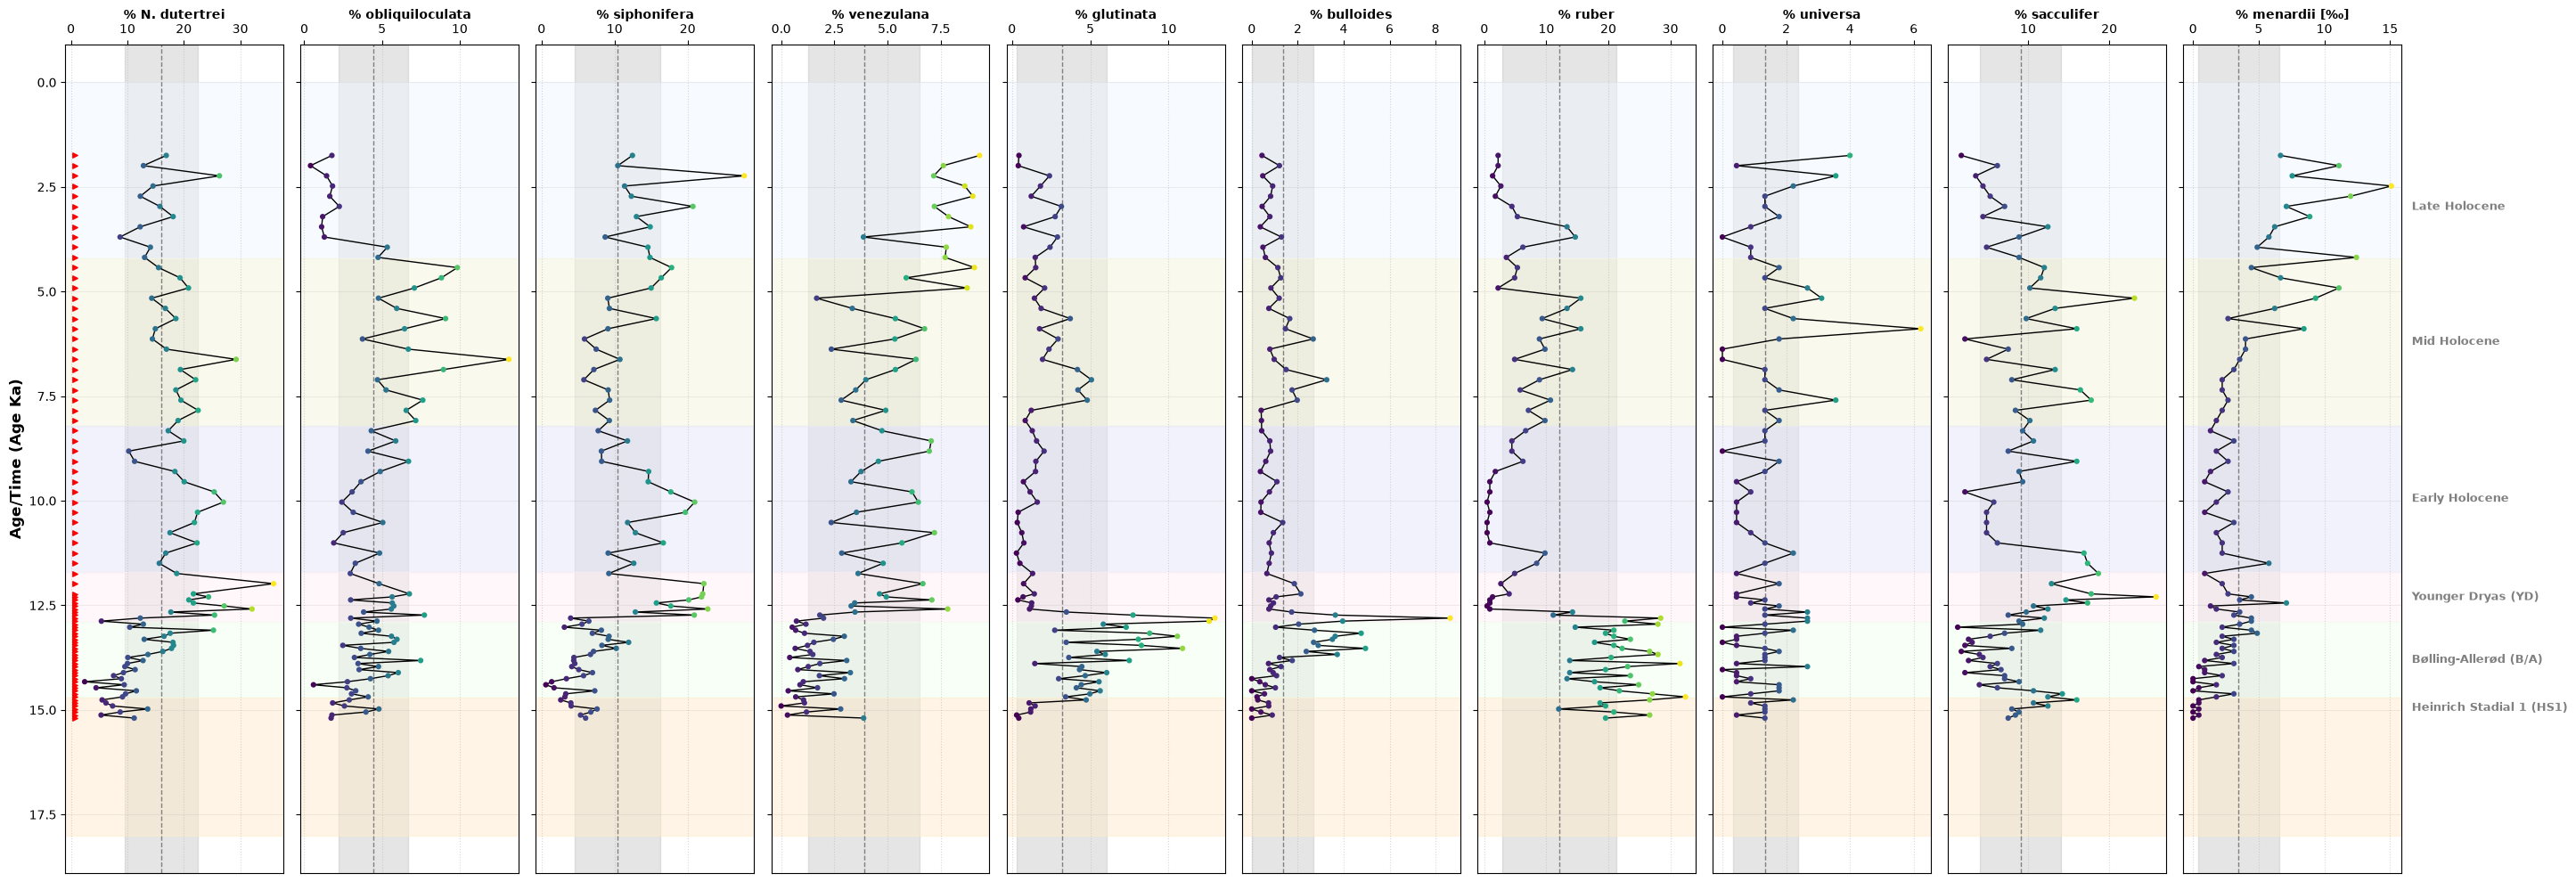

In [26]:
# TIME-SERIES DASHBOARD (do not edit)
# ============================================================
N_proxies = len(PROXY_COLUMNS)

# Create figure with shared Y axis
fig, axes = plt.subplots(1, N_proxies, figsize=(3 * N_proxies, 10), sharey=True)
if N_proxies == 1: axes = [axes]

t_min, t_max = np.min(global_time), np.max(global_time)

# Background shading colors for climatic intervals
bg_colors = ['#f0f8ff', '#f5f5dc', '#e6e6fa', '#fff0f5', '#f0fff0', '#ffebcd']
color_idx = 0

for i, col in enumerate(PROXY_COLUMNS):
    ax = axes[i]
    v = global_proxy_dict[col]
    unit = PROXY_UNITS.get(col, '')
    
    # Plot line + points
    ax.plot(v, global_time, color='black', lw=1, zorder=3)
    ax.scatter(v, global_time, c=v, cmap='viridis', s=20, zorder=4, edgecolor='none')
    
    # Mean line and shading
    v_valid = v[~np.isnan(v)]
    if len(v_valid) > 0:
        mean_v = np.mean(v_valid)
        std_v = np.std(v_valid)
        ax.axvline(mean_v, color='gray', ls='--', lw=1, zorder=1)
        ax.axvspan(mean_v - std_v, mean_v + std_v, color='gray', alpha=0.2, zorder=0)

    # Shaded Climatic Intervals
    for label, (start, end) in CLIMATIC_INTERVALS.items():
        # Only shade if it overlaps with our data
        if start <= t_max and end >= t_min:
            ax.axhspan(start, end, color=bg_colors[color_idx % len(bg_colors)], alpha=0.5, zorder=0)
            
            # Put label only on the rightmost plot
            if i == N_proxies - 1:
                y_center = (max(start, t_min) + min(end, t_max)) / 2
                ax.text(ax.get_xlim()[1] * 1.05, y_center, label, 
                        va='center', ha='left', fontsize=9, color='gray', fontweight='bold')
        color_idx += 1
    color_idx = 0 # reset for next panel to keep colors aligned

    # Formatting
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 
    label_str = f"{col} [{unit}]" if unit else col
    ax.set_xlabel(label_str, fontsize=10, fontweight='bold')
    ax.grid(True, axis='x', ls=':', alpha=0.5)
    ax.grid(True, axis='y', ls='-', alpha=0.2)

# Sample ticks on the leftmost axis
left_ax = axes[0]
valid_time = global_time[~np.isnan(global_proxy_dict[PROXY_COLUMNS[0]])] # use first proxy for tick marks
left_ax.scatter([left_ax.get_xlim()[0]] * len(valid_time), valid_time, 
                marker='>', color='red', s=15, zorder=5, clip_on=False)

left_ax.set_ylabel(f"Age/Time ({AGE_COLUMN})", fontsize=12, fontweight='bold')

# Age axis orientation
if AGE_DIRECTION == 'oldest_right' or AGE_DIRECTION == 'oldest_bottom':
    plt.gca().invert_yaxis()

plt.tight_layout()
plt.subplots_adjust(right=0.9) # make room for interval text
plt.savefig(f"Dashboard_{datetime.datetime.now().strftime('%H%M%S')}.png", dpi=150)
plt.show()

---
## Section 4 · Sampling Regularity & Stationarity

### Sampling Regularity
- CV(Δt) < 0.3: Quasi-uniform sampling.
- CV(Δt) > 0.3: Significantly uneven. Interpolation before spectral analysis is dangerous. (Note: PCA operates on sample-space, not time, so uneven sampling does not mathematically break PCA).

### Stationarity & Detrending (CRITICAL NUANCE)
A stationary series has constant mean and variance through time. 
**Glacial-Interglacial Cycles vs. Monotonic Trends:** The statistical tests below (ADF and KPSS) will often flag proxies as non-stationary simply because of glacial-interglacial cycles. **This is usually the exact signal we want to analyze!** 

Detrending removes baseline shifts. If you detrend an orbital cycle, you destroy your signal. 
*See Section 5 below for the scientific safety measures on how to navigate this.*

- **Augmented Dickey-Fuller (ADF) test:** H₀ = non-stationary (unit root). Want p < 0.05 to reject.
- **KPSS test:** H₀ = stationary. Want p > 0.05 to fail to reject.

In [27]:
# STATIONARITY TESTS (do not edit)
# ============================================================

print("="*60)
print("  STATIONARITY & REGULARITY")
print("="*60)

for col in PROXY_COLUMNS:
    v = global_proxy_dict[col]
    mask = ~np.isnan(v)
    v_valid = v[mask]
    t_valid = global_time[mask]
    
    # Delta t
    dt = np.abs(np.diff(t_valid))
    dt_med = np.median(dt)
    dt_cv = np.std(dt) / dt_med if dt_med > 0 else 0
    
    if len(v_valid) < 10:
        continue
        
    print(f"\n[{col}]")
    print(f"  Δt Median : {dt_med:.3f} | Δt CV: {dt_cv:.2f} ({'Uneven' if dt_cv > 0.3 else 'Uniform'})")
    
    if HAS_STATSMODELS:
        # ADF Test
        adf_stat, adf_p, _, _, _, _ = sm_tsa.adfuller(v_valid, autolag='AIC')
        # KPSS Test
        kpss_stat, kpss_p, _, _ = sm_tsa.kpss(v_valid, regression='c', nlags='auto')
        
        status = "AMBIGUOUS"
        if adf_p < 0.05 and kpss_p > 0.05: status = "STATIONARY"
        elif adf_p > 0.05 and kpss_p < 0.05: status = "NON-STATIONARY"
        
        print(f"  ADF p-value : {adf_p:.3f} (<0.05 = stationary)")
        print(f"  KPSS p-value: {kpss_p:.3f} (>0.05 = stationary)")
        print(f"  Verdict     : {status}")

  STATIONARITY & REGULARITY

[% N. dutertrei]
  Δt Median : 0.244 | Δt CV: 0.35 (Uneven)
  ADF p-value : 0.015 (<0.05 = stationary)
  KPSS p-value: 0.019 (>0.05 = stationary)
  Verdict     : AMBIGUOUS

[% obliquiloculata]
  Δt Median : 0.244 | Δt CV: 0.35 (Uneven)
  ADF p-value : 0.414 (<0.05 = stationary)
  KPSS p-value: 0.100 (>0.05 = stationary)
  Verdict     : AMBIGUOUS

[% siphonifera]
  Δt Median : 0.244 | Δt CV: 0.35 (Uneven)
  ADF p-value : 0.076 (<0.05 = stationary)
  KPSS p-value: 0.016 (>0.05 = stationary)
  Verdict     : NON-STATIONARY

[% venezulana]
  Δt Median : 0.244 | Δt CV: 0.35 (Uneven)
  ADF p-value : 0.820 (<0.05 = stationary)
  KPSS p-value: 0.010 (>0.05 = stationary)
  Verdict     : NON-STATIONARY

[% glutinata]
  Δt Median : 0.244 | Δt CV: 0.35 (Uneven)
  ADF p-value : 0.003 (<0.05 = stationary)
  KPSS p-value: 0.069 (>0.05 = stationary)
  Verdict     : STATIONARY

[% bulloides]
  Δt Median : 0.244 | Δt CV: 0.35 (Uneven)
  ADF p-value : 0.141 (<0.05 = stationary

---
## Section 5 · Stationarity Mitigation (Safety Measures)

If your proxy was flagged as NON-STATIONARY, how do you navigate it without destroying the climate signal you want to study?

1. **Do Nothing (Accept non-stationarity):** Often the mathematically correct choice if the non-stationarity is driven by legitimate orbital/glacial cycles.
2. **First-Differencing ($x_t - x_{t-1}$):** If the data is severely non-stationary (a random walk) and you only care about short-term *changes* rather than absolute states. Note: this changes the physical meaning of the proxy from "temperature" to "rate of temperature change".
3. **Frequency-Domain Bandpass Filtering:** If a >1-million-year monotonic cooling trend is drowning out the millennial-scale noise, simple linear detrending is risky. A more robust approach is filtering, which mathematically isolates the 10ka–400ka orbital band while explicitly ignoring the low-frequency drift.

In [28]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        USER INPUT BLOCK 3 — Stationarity Mitigation         ║
# ╚══════════════════════════════════════════════════════════════╝

MITIGATION_STRATEGY = 'none'   # 'none', 'difference', 'bandpass', 'linear_detrend'

# Bandpass settings (only used if MITIGATION_STRATEGY == 'bandpass')
# Units are in your AGE_COLUMN units (e.g., ka)
BANDPASS_LOW_CUTOFF  = 10.0    # Retain cycles slower than this
BANDPASS_HIGH_CUTOFF = 400.0   # Retain cycles faster than this

In [29]:
# MITIGATION EXECUTION (do not edit)
# ============================================================
global_proxy_dict_mitigated = {}

if MITIGATION_STRATEGY == 'none':
    print("No stationarity mitigation applied. Proceeding with raw data.")
    global_proxy_dict_mitigated = {k: v.copy() for k, v in global_proxy_dict.items()}

else:
    print(f"Applying mitigation: {MITIGATION_STRATEGY.upper()}")
    
    fig, axes = plt.subplots(len(PROXY_COLUMNS), 1, figsize=(10, 2*len(PROXY_COLUMNS)), sharex=True)
    if len(PROXY_COLUMNS) == 1: axes = [axes]
    
    for i, col in enumerate(PROXY_COLUMNS):
        v = global_proxy_dict[col].copy()
        mask = ~np.isnan(v)
        v_valid = v[mask]
        t_valid = global_time[mask]
        
        v_mit = v_valid.copy()
        
        if MITIGATION_STRATEGY == 'difference':
            # Prepend a 0 to keep shape identical (first point has no diff)
            diffs = np.diff(v_valid)
            v_mit = np.concatenate([[0], diffs])
            
        elif MITIGATION_STRATEGY == 'linear_detrend':
            from scipy.signal import detrend
            v_mit = detrend(v_valid, type='linear')
            
        elif MITIGATION_STRATEGY == 'bandpass':
            # Bandpass requires evenly spaced data. 
            # We interpolate, filter, and extract back to original time points.
            dt_med = np.median(np.abs(np.diff(t_valid)))
            t_even = np.arange(np.min(t_valid), np.max(t_valid), dt_med)
            v_even = np.interp(t_even, t_valid, v_valid)
            
            # Scipy Butterworth filter
            nyq = 0.5 * (1.0 / dt_med)
            low = (1.0 / BANDPASS_HIGH_CUTOFF) / nyq
            high = (1.0 / BANDPASS_LOW_CUTOFF) / nyq
            
            # Ensure frequencies are valid
            if 0 < low < high < 1:
                b, a = butter(4, [low, high], btype='band')
                v_filt = filtfilt(b, a, v_even)
                # Map back to original uneven time points
                v_mit = np.interp(t_valid, t_even, v_filt)
            else:
                print(f"[{col}] Bandpass failed: Cutoffs ({BANDPASS_LOW_CUTOFF}, {BANDPASS_HIGH_CUTOFF}) invalid for sampling resolution {dt_med:.2f}. Leaving unaltered.")
                v_mit = v_valid

        # Store back in global dict preserving NaNs
        v_out = np.full_like(v, np.nan)
        v_out[mask] = v_mit
        global_proxy_dict_mitigated[col] = v_out
        
        # Plot Before vs After
        ax = axes[i]
        ax.plot(t_valid, v_valid, color='lightgray', lw=2, label='Original')
        
        # Scale mitigated to overlay nicely for visual comparison
        scale_factor = np.std(v_valid) / (np.std(v_mit) if np.std(v_mit) != 0 else 1)
        v_mit_scaled = (v_mit - np.mean(v_mit)) * scale_factor + np.mean(v_valid)
        
        ax.plot(t_valid, v_mit_scaled, color='blue', lw=1, alpha=0.8, label=f'{MITIGATION_STRATEGY} (scaled)')
        ax.set_ylabel(col)
        if i == 0: ax.legend(loc='upper right')

    axes[-1].set_xlabel(AGE_COLUMN)
    if AGE_DIRECTION == 'oldest_right': plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.show()

No stationarity mitigation applied. Proceeding with raw data.


---
## Section 6 · Distribution Analysis & Transforms

Standard PCA is optimal when variables are normally distributed. If a species has mostly near-zero values with a few extreme abundance spikes (highly right-skewed), it violates this assumption.

**State of the Art Transformations:**
We provide automated power transformations that mathematically find the optimal normal shape:

| Transform | When to use | 
|---|---|
| `none` | Normal-ish or Bimodal (Do NOT transform bimodal glacial/interglacial modes!) | 
| `log1p` or `sqrt` | Simple handling for right-skewed, positive species counts | 
| `arcsin_sqrt` | Specifically for compositional data bounded 0–100% | 
| `yeo-johnson` | **(Recommended)** Works on positive, negative, and zero data. Automatically optimizes $\lambda$ to induce normality. | 
| `box-cox` | Finds optimal $\lambda$, but fails if data contains zeros or negatives. |

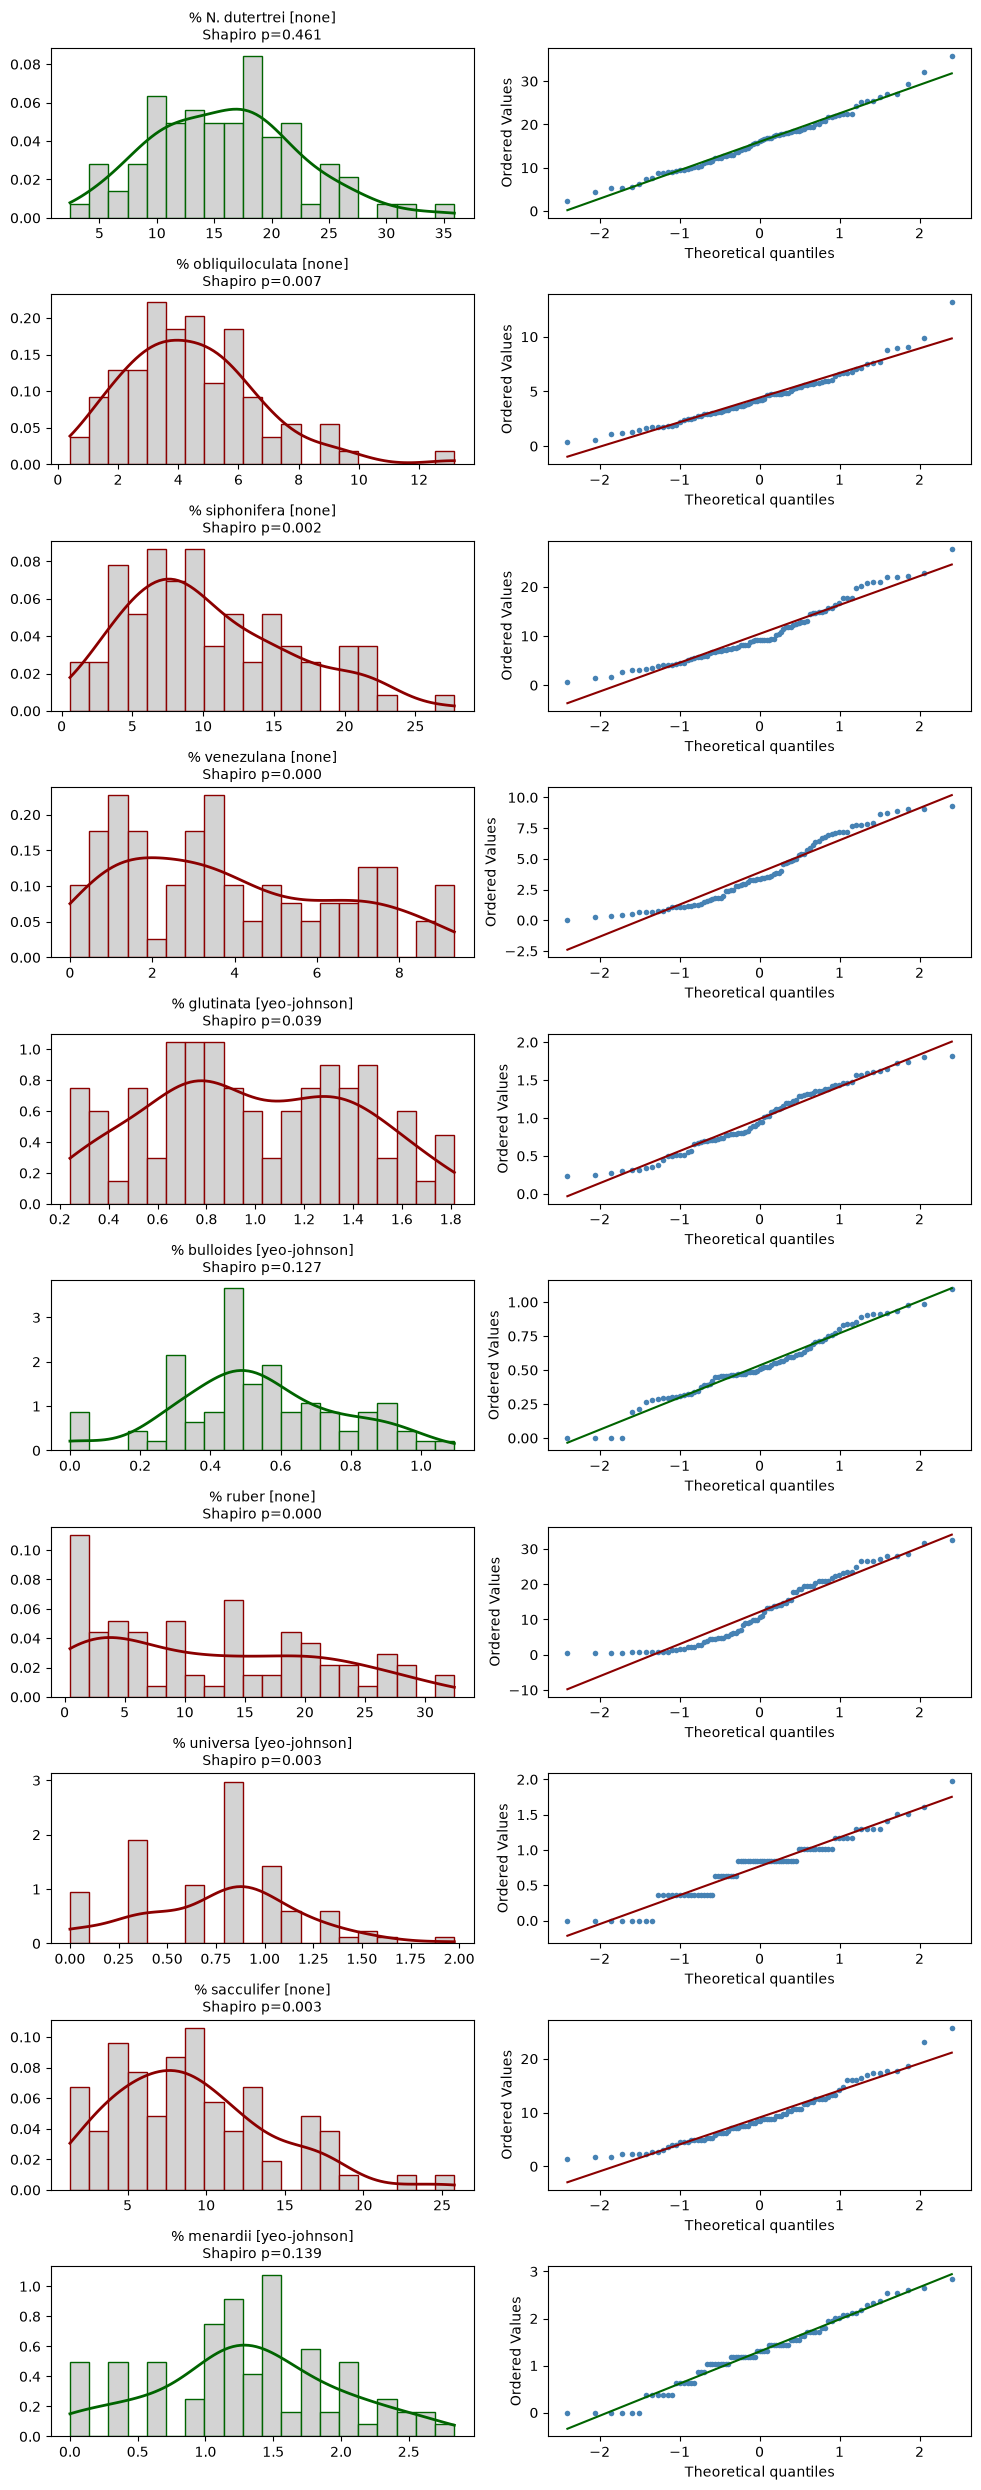

Transformed data saved to global dictionary. Ready for Correlation and PCA.


In [30]:
# TRANSFORMATIONS (do not edit)
# ============================================================
# Automatically apply Yeo-Johnson to variables with skewness > 1

global_proxy_dict_trans = {}

fig, axes = plt.subplots(len(PROXY_COLUMNS), 2, figsize=(10, 2.5 * len(PROXY_COLUMNS)))
if len(PROXY_COLUMNS) == 1: axes = [axes]

for i, col in enumerate(PROXY_COLUMNS):
    # Use the mitigated data as the base
    v = global_proxy_dict_mitigated[col]
    mask = ~np.isnan(v)
    v_valid = v[mask]
    
    skew = stats.skew(v_valid)
    
    # Auto-decision: Transform if highly skewed
    transform_used = 'none'
    v_trans = v_valid.copy()
    
    if np.abs(skew) > 1.0:
        transform_used = 'yeo-johnson'
        v_trans, lmbda = stats.yeojohnson(v_valid)
    
    # Reassemble with NaNs
    v_out = np.full_like(v, np.nan)
    v_out[mask] = v_trans
    global_proxy_dict_trans[col] = v_out
    
    # Normality test on transformed
    _, p_val = stats.shapiro(v_trans)
    border_color = 'darkgreen' if p_val > 0.05 else 'darkred'
    
    # Plot Histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(v_trans, bins=20, density=True, color='lightgray', edgecolor=border_color)
    kde = stats.gaussian_kde(v_trans)
    x_k = np.linspace(np.min(v_trans), np.max(v_trans), 100)
    ax_hist.plot(x_k, kde(x_k), color=border_color, lw=2)
    ax_hist.set_title(f"{col} [{transform_used}]\nShapiro p={p_val:.3f}", fontsize=10)
    
    # Plot Q-Q
    ax_qq = axes[i, 1]
    stats.probplot(v_trans, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_markerfacecolor('steelblue')
    ax_qq.get_lines()[0].set_markeredgecolor('none')
    ax_qq.get_lines()[0].set_markersize(4)
    ax_qq.get_lines()[1].set_color(border_color)
    ax_qq.set_title("")

plt.tight_layout()
plt.show()

print("Transformed data saved to global dictionary. Ready for Correlation and PCA.")

---
## Section 7 · Correlation in Autocorrelated Data

> **WARNING:** Standard Pearson *r* assumes every observation is independent. Geological time series are autocorrelated — the temperature today is highly dependent on the temperature yesterday. This inflates the effective degrees of freedom and makes standard p-values *wildly over-optimistic.*

If you ignore autocorrelation, you will routinely find "statistically significant" correlations between completely unrelated proxies just because they both have long-term memory (red noise).

### How to correct for it:
1. **Bartlett (1946) Effective Sample Size ($N_{eff}$):** 
   We estimate the lag-1 autocorrelation ($\rho_1$, $\rho_2$) of both proxies and reduce the sample size using the formula:
   $N_{eff} = N \frac{1 - \rho_1 \rho_2}{1 + \rho_1 \rho_2}$
   The p-value is then recomputed using this much smaller, realistic sample size.

2. **Isospectral Phase Randomization (Surrogates):**
   *This is the gold standard.* We take your proxy data, jump into the frequency domain using an FFT, randomize the phases, and jump back to the time domain. This creates "fake" data (a surrogate) that has the exact same autocorrelation (power spectrum) as your real data, but the physical relationship is destroyed. 
   By correlating 1,000 pairs of these surrogates, we build an empirical null distribution. If your observed correlation is stronger than 95% of the surrogate correlations, it is truly significant ($p < 0.05$).

In [31]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        USER INPUT BLOCK 4 — Correlation Settings            ║
# ╚══════════════════════════════════════════════════════════════╝

CORR_METHOD        = 'pearson'        # 'pearson', 'spearman', or 'kendall'
AUTOCORR_CORRECT   = True             # Apply Bartlett's N_eff correction (highly recommended)
N_SURROGATES       = 1000             # Phase-randomization surrogates (0 = skip). Takes ~2 seconds.
CORR_SEED          = 42               # Reproducibility seed for surrogates
SIGNIFICANCE_LEVEL = 0.05             # α for significance testing (typically 0.05)

  CORRELATION MATRIX (PEARSON)
  Significance level: α = 0.05



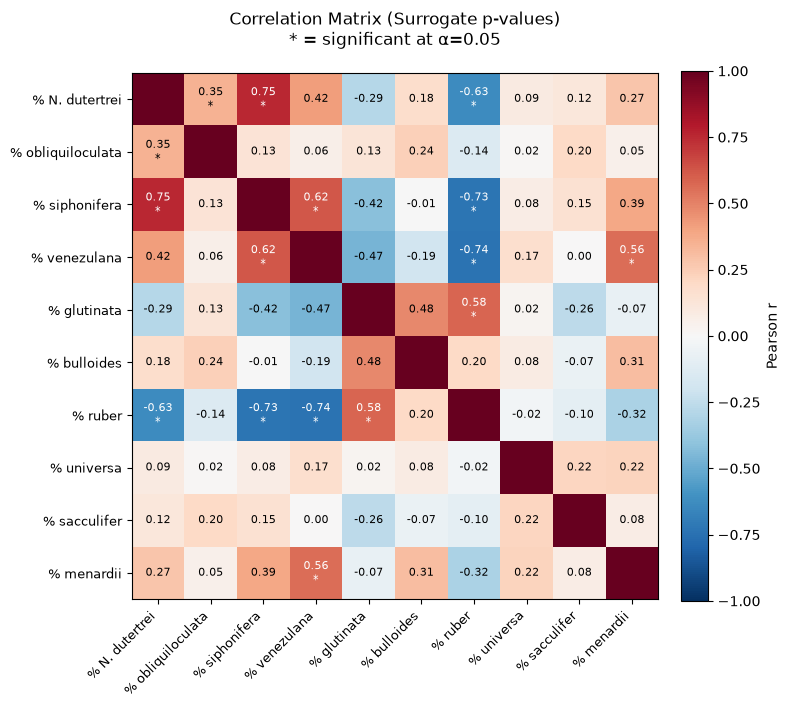


  Significant pairs (α=0.05, Surrogate):
  Pair                                     r |   Uncorr p |     Corr p |     Surr p
  ---------------------------------------------------------------------------
  % N. dutertrei & % obliquilocu...     0.35 |     0.0011 |     0.0204 |     0.0430
  % N. dutertrei & % siphonifera        0.75 |     0.0000 |     0.0000 |     0.0000
  % N. dutertrei & % ruber             -0.63 |     0.0000 |     0.0002 |     0.0040
  % siphonifera & % venezulana          0.62 |     0.0000 |     0.0001 |     0.0030
  % siphonifera & % ruber              -0.73 |     0.0000 |     0.0000 |     0.0000
  % venezulana & % ruber               -0.74 |     0.0000 |     0.0000 |     0.0000
  % venezulana & % menardii             0.56 |     0.0000 |     0.0006 |     0.0040
  % glutinata & % ruber                 0.58 |     0.0000 |     0.0031 |     0.0060


In [32]:
# CORRELATION ANALYSIS (do not edit)
# ============================================================
np.random.seed(CORR_SEED)

def _get_ar1(series):
    '''Estimate lag-1 autocorrelation using Scipy correlate.'''
    s = series[~np.isnan(series)]
    if len(s) < 3: return 0.0
    c = correlate(s - np.mean(s), s - np.mean(s), mode='full')
    c = c[len(s)-1:] / c[len(s)-1]
    return c[1] if len(c) > 1 else 0.0

def _phase_randomize(series):
    '''Generate an isospectral surrogate via FFT phase randomization.'''
    s = series.copy()
    mask = ~np.isnan(s)
    v = s[mask]
    if len(v) < 3: return s
    F = np.fft.rfft(v)
    angles = np.random.uniform(0, 2*np.pi, len(F))
    F_surr = np.abs(F) * np.exp(1j * angles)
    s[mask] = np.fft.irfft(F_surr, n=len(v))
    return s

_N = len(PROXY_COLUMNS)
corr_mat = np.zeros((_N, _N))
pval_uncorr = np.zeros((_N, _N))
pval_corr   = np.zeros((_N, _N))
pval_surr   = np.zeros((_N, _N)) if N_SURROGATES > 0 else None

# Pre-calculate AR(1) for N_eff
_ar1 = {col: _get_ar1(global_proxy_dict_trans[col]) for col in PROXY_COLUMNS}

print("=" * 60)
print(f"  CORRELATION MATRIX ({CORR_METHOD.upper()})")
print("=" * 60)
print(f"  Significance level: α = {SIGNIFICANCE_LEVEL}\n")

for i in range(_N):
    for j in range(_N):
        if i == j:
            corr_mat[i,j] = 1.0
            continue
            
        c1, c2 = PROXY_COLUMNS[i], PROXY_COLUMNS[j]
        v1, v2 = global_proxy_dict_trans[c1], global_proxy_dict_trans[c2]
        
        # Intersection mask
        mask = ~np.isnan(v1) & ~np.isnan(v2)
        n = mask.sum()
        if n < 3:
            corr_mat[i,j] = pval_uncorr[i,j] = pval_corr[i,j] = np.nan
            continue
            
        # Raw correlation
        if CORR_METHOD == 'pearson':
            r, p = stats.pearsonr(v1[mask], v2[mask])
        elif CORR_METHOD == 'spearman':
            r, p = stats.spearmanr(v1[mask], v2[mask])
        elif CORR_METHOD == 'kendall':
            r, p = stats.kendalltau(v1[mask], v2[mask])
            
        corr_mat[i,j] = r
        pval_uncorr[i,j] = p
        
        # Bartlett correction
        if AUTOCORR_CORRECT:
            rho1, rho2 = _ar1[c1], _ar1[c2]
            n_eff = max(3, n * ((1 - rho1*rho2) / (1 + rho1*rho2)))
            t_stat = r * np.sqrt((n_eff - 2) / (1 - r**2 + 1e-12))
            pval_corr[i,j] = 2 * stats.t.sf(np.abs(t_stat), df=n_eff-2)
        else:
            pval_corr[i,j] = p
            
        # Surrogates
        if N_SURROGATES > 0 and i < j:
            surr_rs = []
            for _ in range(N_SURROGATES):
                s1 = _phase_randomize(v1)[mask]
                s2 = _phase_randomize(v2)[mask]
                
                if CORR_METHOD == 'pearson':
                    sr, _ = stats.pearsonr(s1, s2)
                elif CORR_METHOD == 'spearman':
                    sr, _ = stats.spearmanr(s1, s2)
                else:
                    sr, _ = stats.kendalltau(s1, s2)
                surr_rs.append(sr)
            
            # Empirical p-value
            pval_surr[i,j] = pval_surr[j,i] = np.sum(np.abs(surr_rs) >= np.abs(r)) / N_SURROGATES

# Determine which p-value defines the asterisks on the plot
if N_SURROGATES > 0:
    _p_active = pval_surr
    _p_label  = "Surrogate"
elif AUTOCORR_CORRECT:
    _p_active = pval_corr
    _p_label  = "N_eff corrected"
else:
    _p_active = pval_uncorr
    _p_label  = "Uncorrected (DANGEROUS)"

# Plotting heatmap
fig, ax = plt.subplots(figsize=(max(6, _N*0.8), max(6, _N*0.8)))
im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label=f"{CORR_METHOD.capitalize()} r")

ax.set_xticks(np.arange(_N))
ax.set_yticks(np.arange(_N))
ax.set_xticklabels(PROXY_COLUMNS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(PROXY_COLUMNS, fontsize=9)

for i in range(_N):
    for j in range(_N):
        if i == j: continue
        val = corr_mat[i,j]
        if np.isnan(val): continue
        
        text = f"{val:.2f}"
        if _p_active[i,j] < SIGNIFICANCE_LEVEL:
            text += "\n*"
        
        ax.text(j, i, text, ha="center", va="center", 
                color="white" if np.abs(val) > 0.5 else "black", fontsize=8)

ax.set_title(f"Correlation Matrix ({_p_label} p-values)\n* = significant at α={SIGNIFICANCE_LEVEL}", pad=20)
plt.tight_layout()
plt.savefig(f"CorrelationMatrix_{CORR_METHOD}.png", dpi=150)
plt.show()

# Print detailed summary
print(f"\n  Significant pairs (α={SIGNIFICANCE_LEVEL}, {_p_label}):")
print(f"  {'Pair':<35} {'r':>6} | {'Uncorr p':>10} | {'Corr p':>10} | {'Surr p':>10}")
print("  " + "-"*75)
for i in range(_N):
    for j in range(i+1, _N):
        if _p_active[i,j] < SIGNIFICANCE_LEVEL:
            p_unc = f"{pval_uncorr[i,j]:.4f}"
            p_cor = f"{pval_corr[i,j]:.4f}" if AUTOCORR_CORRECT else "N/A"
            p_sur = f"{pval_surr[i,j]:.4f}" if N_SURROGATES > 0 else "N/A"
            pair = f"{PROXY_COLUMNS[i]} & {PROXY_COLUMNS[j]}"
            if len(pair) > 33: pair = pair[:30] + "..."
            print(f"  {pair:<35} {corr_mat[i,j]:>6.2f} | {p_unc:>10} | {p_cor:>10} | {p_sur:>10}")

---
## Section 8 · Cross-Proxy Scatter Matrix

The correlation matrix in Section 7 only captures linear (Pearson) or monotonic (Spearman) relationships. It will completely fail to describe nonlinear dynamics (e.g., if Proxy A rises with Proxy B up to a certain threshold and then flatlines). 

- **Off-diagonal panels:** Scatter plots of every proxy against every other proxy.
- **Color:** Points are colored by Age (blue = older, red = younger). This helps you visually identify if a relationship changes state over time (e.g., they are correlated during glacials, but uncorrelated during interglacials).
- **Diagonal panels:** The probability density (KDE) of each proxy.

Note: Displaying scatter matrix for first 6 proxies only.


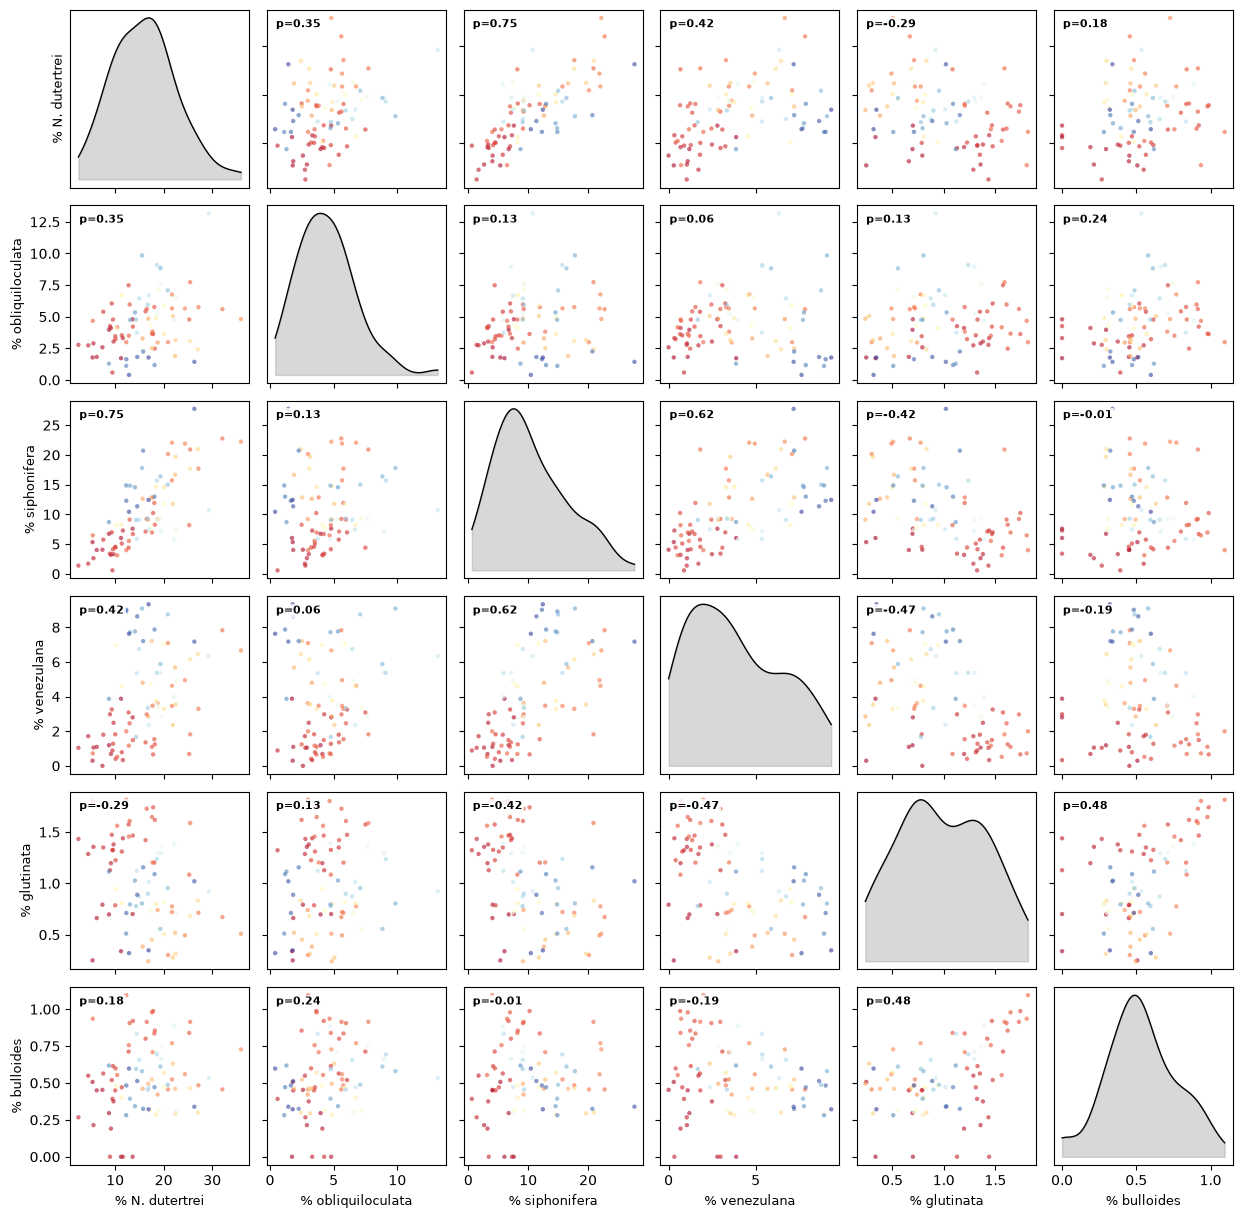

In [33]:
# SCATTER MATRIX (do not edit)
# ============================================================
# Limit to 6 proxies maximum for readability
_disp_cols = PROXY_COLUMNS[:6]
_M = len(_disp_cols)

if len(PROXY_COLUMNS) > 6:
    print(f"Note: Displaying scatter matrix for first 6 proxies only.")

fig, axes = plt.subplots(_M, _M, figsize=(2.5*_M, 2.5*_M))
if _M == 1: axes = np.array([[axes]])

_tnorm = Normalize(vmin=np.nanmin(global_time), vmax=np.nanmax(global_time))

for i, c_row in enumerate(_disp_cols):
    for j, c_col in enumerate(_disp_cols):
        ax = axes[i, j]
        v_row = global_proxy_dict_trans[c_row]
        v_col = global_proxy_dict_trans[c_col]
        
        if i == j:
            # Diagonal: KDE
            vc = v_row[~np.isnan(v_row)]
            if len(vc) > 3:
                kde = stats.gaussian_kde(vc)
                x_k = np.linspace(vc.min(), vc.max(), 100)
                ax.fill_between(x_k, 0, kde(x_k), color='gray', alpha=0.3)
                ax.plot(x_k, kde(x_k), color='black', lw=1)
            ax.set_yticks([])
        else:
            # Off-diagonal: Scatter
            mask = ~np.isnan(v_row) & ~np.isnan(v_col)
            if mask.sum() > 0:
                ax.scatter(v_col[mask], v_row[mask], c=global_time[mask], 
                           cmap='RdYlBu_r', norm=_tnorm, s=10, alpha=0.6, edgecolors='none')
                
                # Annotate basic correlation
                if CORR_METHOD == 'pearson':
                    r, _ = stats.pearsonr(v_col[mask], v_row[mask])
                elif CORR_METHOD == 'spearman':
                    r, _ = stats.spearmanr(v_col[mask], v_row[mask])
                else:
                    r, _ = stats.kendalltau(v_col[mask], v_row[mask])
                    
                ax.text(0.05, 0.95, f"{CORR_METHOD[0]}={r:.2f}", transform=ax.transAxes, 
                        ha='left', va='top', fontsize=8, fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
                
        # Subplot formatting
        if i == _M - 1:
            ax.set_xlabel(c_col, fontsize=9)
        else:
            ax.set_xticklabels([])
            
        if j == 0:
            ax.set_ylabel(c_row, fontsize=9)
        else:
            ax.set_yticklabels([])

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig("ScatterMatrix.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 · Cross-Correlation Functions (Lagged)

The correlation matrix in Section 7 assumes two proxies rise and fall *at the exact same time* (zero lag). 

However, the climate system has massive thermal inertia and ecological delays. Sea surface temperature might rise 2,000 years *before* global ice volume responds. If you only look at zero-lag correlation, you might conclude they are unrelated!

The **Cross-Correlation Function (CCF)** tests correlation at various physical time shifts (lags).
- X-axis = Lag in time units (e.g., ka).
- A peak at **Lag > 0** means Proxy 1 *leads* Proxy 2.
- A peak at **Lag < 0** means Proxy 1 *lags* Proxy 2.
- The dashed red lines are the $95\%$ significance bounds (adjusted for autocorrelation using $N_{eff}$). Peaks crossing these lines are statistically significant.

*Note: Because paleoclimate data is unevenly spaced, we cannot use standard signal processing directly. We interpolate the data to a regular median-Δt grid strictly for this CCF visualization.*

Calculating CCF up to ±5.0 time units...


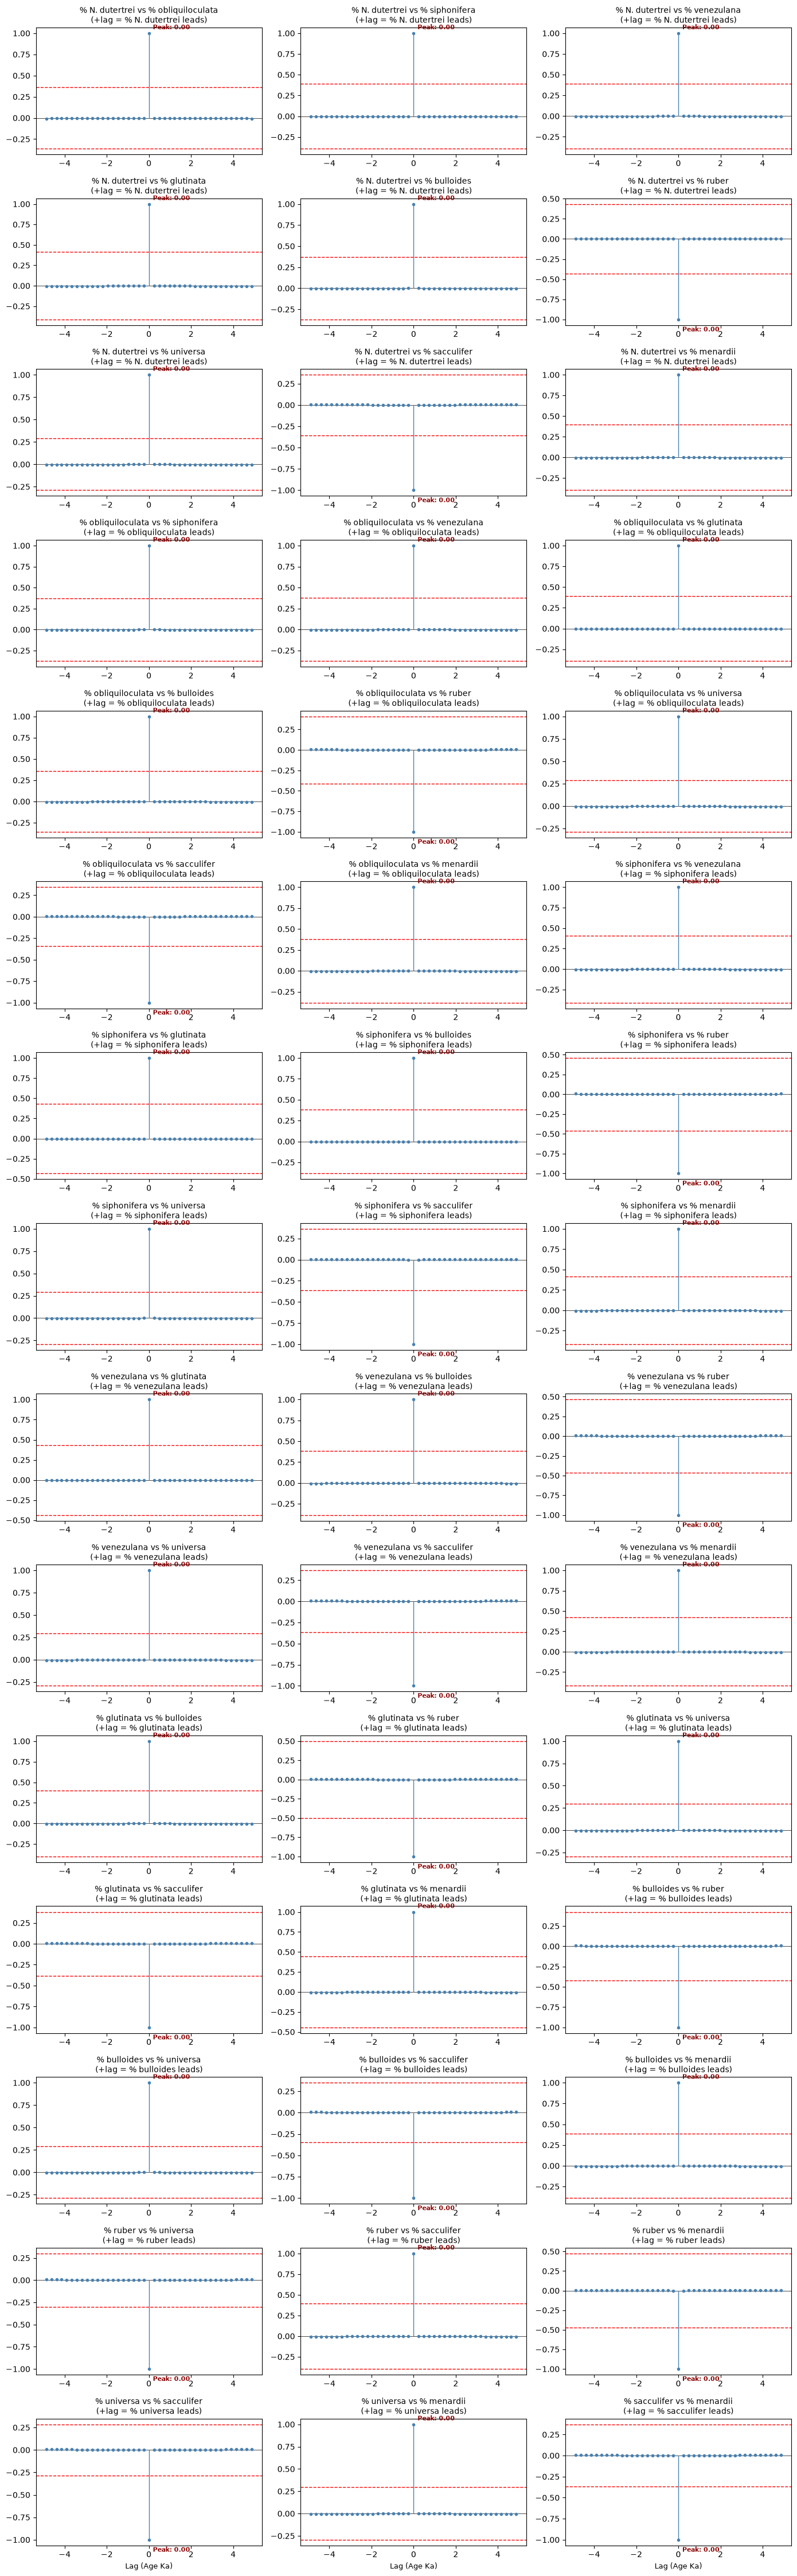

In [34]:
# LAGGED CROSS-CORRELATION (do not edit)
# ============================================================
CCF_MAX_LAG = 5.0   # Maximum lag to calculate in units of AGE_COLUMN (e.g., 5 ka)

print(f"Calculating CCF up to ±{CCF_MAX_LAG} time units...")

# Create a regular time grid for CCF (using median dt)
# (Using the un-nan global time)
_dt_med = np.median(np.abs(np.diff(global_time)))
if _dt_med == 0: _dt_med = 0.1
_t_reg = np.arange(np.min(global_time), np.max(global_time), _dt_med)

_N_pairs = _N * (_N - 1) // 2
_cols = 3
_rows = int(np.ceil(_N_pairs / _cols))

fig, axes = plt.subplots(_rows, _cols, figsize=(14, 3*_rows))
axes = axes.flatten()

plot_idx = 0
for i in range(_N):
    for j in range(i+1, _N):
        ax = axes[plot_idx]
        c1, c2 = PROXY_COLUMNS[i], PROXY_COLUMNS[j]
        
        # Interpolate to regular grid
        mask1 = ~np.isnan(global_proxy_dict_trans[c1])
        mask2 = ~np.isnan(global_proxy_dict_trans[c2])
        if mask1.sum() < 5 or mask2.sum() < 5:
            ax.text(0.5, 0.5, "Insufficient data", ha='center')
            plot_idx += 1
            continue
            
        v1_reg = np.interp(_t_reg, global_time[mask1], global_proxy_dict_trans[c1][mask1])
        v2_reg = np.interp(_t_reg, global_time[mask2], global_proxy_dict_trans[c2][mask2])
        
        # Standardize for CCF
        v1_reg = (v1_reg - np.mean(v1_reg)) / np.std(v1_reg)
        v2_reg = (v2_reg - np.mean(v2_reg)) / np.std(v2_reg)
        
        # Calculate CCF
        n = len(v1_reg)
        ccf = correlate(v1_reg, v2_reg, mode='full') / n
        lags = np.arange(-(n-1), n) * _dt_med
        
        # Filter to max lag window
        valid_lags = np.abs(lags) <= CCF_MAX_LAG
        ccf = ccf[valid_lags]
        lags = lags[valid_lags]
        
        # Significance bounds (approximate, N_eff)
        rho1, rho2 = _ar1[c1], _ar1[c2]
        n_eff = n * ((1 - rho1*rho2) / (1 + rho1*rho2))
        bound = 1.96 / np.sqrt(max(3, n_eff))
        
        ax.axhline(0, color='black', lw=0.5)
        ax.axhline(bound, color='red', ls='--', lw=1)
        ax.axhline(-bound, color='red', ls='--', lw=1)
        
        # Stem plot for lags
        markerline, stemlines, baseline = ax.stem(lags, ccf, basefmt=" ")
        plt.setp(markerline, markersize=3, color='steelblue')
        plt.setp(stemlines, color='steelblue', lw=1)
        
        # Identify peak
        peak_idx = np.argmax(np.abs(ccf))
        peak_lag = lags[peak_idx]
        peak_val = ccf[peak_idx]
        
        ax.annotate(f"Peak: {peak_lag:.2f}", xy=(peak_lag, peak_val), 
                    xytext=(5, 5 if peak_val>0 else -15), textcoords='offset points',
                    fontsize=8, color='darkred', fontweight='bold')
        
        ax.set_title(f"{c1} vs {c2}\n(+lag = {c1} leads)", fontsize=10)
        if plot_idx >= _N_pairs - _cols:
            ax.set_xlabel(f"Lag ({AGE_COLUMN})", fontsize=9)
            
        plot_idx += 1

# Hide any unused axes
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig("CCF_Plots.png", dpi=150)
plt.show()

---
<a id='section-10'></a>
## Section 10: Theory — PCA Mathematics

**Principal Component Analysis (PCA)** converts a set of correlated variables (our proxies) into a set of linearly uncorrelated variables (Principal Components).

**Mathematical Nuances for Paleoclimate:**
1. **Standardization:** Since proxies have different units (e.g., % vs. isotope ratios), we typically standardize all variables (Z-score).
2. **Missing Data:** PCA requires a complete matrix. In paleoclimate, we often only apply PCA to the overlapping time window of all proxies. Our notebook operates on the overlapping window (drop NA) to avoid interpolation artifacts.
3. **Bootstrapping:** We use a non-parametric bootstrap to calculate confidence intervals on the PCA loadings.

---
## PCA Parameter Reference
- `N_COMPONENTS`: How many Principal Components to calculate. Usually 2 to 4.
- `STANDARDIZE`: `True` to use Z-scores (correlation matrix PCA), `False` to use raw variance (covariance matrix PCA).
- `N_BOOTSTRAP`: Number of iterations for calculating loading confidence intervals.

In [16]:
# ╔═══════════════════════════════════════════════
# USER INPUT BLOCK 5 — PCA Parameters
# ╚═══════════════════════════════════════════════
N_COMPONENTS = 3       # Number of components to extract
STANDARDIZE = True     # True is highly recommended for multi-proxy data
N_BOOTSTRAP = 1000     # Number of bootstrap samples for confidence intervals

In [38]:
# PCA EXECUTION (do not edit)
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("--- EXECUTING PCA ---")

# 1. Prepare Data Matrix (drop missing rows for pure PCA without interpolation)
pca_data = df_clean[PROXY_COLUMNS].dropna()
pca_age = df_clean.loc[pca_data.index, AGE_COLUMN]

print(f"Original shape: {df_clean.shape[0]} rows. After dropping NAs: {pca_data.shape[0]} rows.")

# 2. Standardization
scaler = StandardScaler() if STANDARDIZE else None
X_scaled = scaler.fit_transform(pca_data) if STANDARDIZE else pca_data.values

# 3. Main PCA
pca = PCA(n_components=min(N_COMPONENTS, pca_data.shape[1]))
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

explained_variance = pca.explained_variance_ratio_ * 100
print(f"Explained Variance by first {pca.n_components_} PCs: {np.sum(explained_variance):.2f}%")

# 4. Bootstrapping Loadings
loadings_boot = np.zeros((N_BOOTSTRAP, pca.n_components_, pca_data.shape[1]))
for i in range(N_BOOTSTRAP):
    idx = np.random.choice(np.arange(X_scaled.shape[0]), size=X_scaled.shape[0], replace=True)
    X_boot = X_scaled[idx, :]
    pca_b = PCA(n_components=pca.n_components_)
    pca_b.fit(X_boot)
    # Procrustes alignment (simple sign flip correction for dominant loadings)
    for c in range(pca.n_components_):
        if np.dot(pca_b.components_[c], pca.components_[c]) < 0:
            pca_b.components_[c] *= -1
    loadings_boot[i, :, :] = pca_b.components_

loadings_mean = np.mean(loadings_boot, axis=0)
loadings_std = np.std(loadings_boot, axis=0)

loadings_df = pd.DataFrame(pca.components_.T, index=PROXY_COLUMNS, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
print("\nPCA Loadings (Eigenvectors):")
display(loadings_df.round(3))

--- EXECUTING PCA ---
Original shape: 85 rows. After dropping NAs: 85 rows.
Explained Variance by first 3 PCs: 66.83%

PCA Loadings (Eigenvectors):


,PC1,PC2,PC3
% N. dutertrei,-0.364,0.328,-0.322
% obliquiloculata,-0.089,0.356,-0.484
% siphonifera,-0.436,0.184,-0.107
% venezulana,-0.439,0.013,0.263
% glutinata,0.360,0.458,0.063
% bulloides,0.210,0.627,0.058
% ruber,0.473,0.026,0.074
% universa,-0.073,0.307,0.434
% sacculifer,-0.115,0.064,-0.148
% menardii,-0.245,0.173,0.599


---
<a id='section-11'></a>
## Section 11: Scree Plot & Significance (Parallel Analysis)

How many Principal Components represent true signal vs. random noise?
- **Scree Plot:** Visualizes the variance explained by each PC.
- **Broken-Stick Model:** A null model assuming variance is divided randomly. If a PC's variance is below the broken-stick line, it's considered noise.
- **Parallel Analysis:** Simulates random noise matrices of the same shape, calculates their eigenvalues, and compares them to our real eigenvalues. This is the gold standard for PC retention.

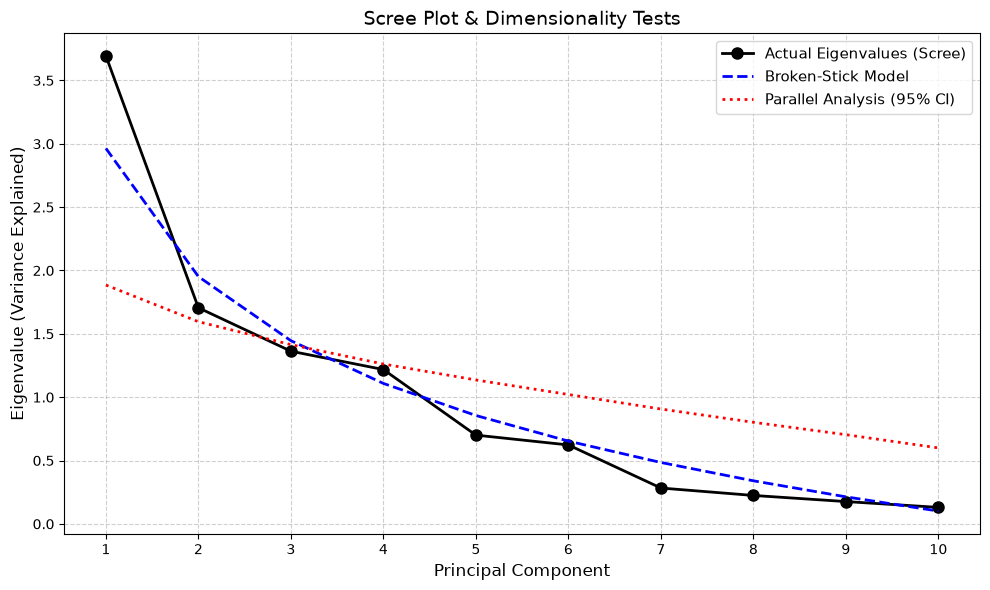

In [39]:
# SCREE PLOT & PARALLEL ANALYSIS (do not edit)
import matplotlib.pyplot as plt

# Calculate all eigenvalues for Scree plot
pca_full = PCA()
pca_full.fit(X_scaled)
eigenvalues = pca_full.explained_variance_

# 1. Broken-Stick
p = len(PROXY_COLUMNS)
broken_stick = np.zeros(p)
for k in range(p):
    broken_stick[k] = np.sum([1.0/i for i in range(k+1, p+1)]) / p
broken_stick *= np.sum(eigenvalues) # Scale to total variance

# 2. Parallel Analysis (Monte Carlo)
N_SIM = 1000
sim_eigenvalues = np.zeros((N_SIM, p))
for i in range(N_SIM):
    X_sim = np.random.normal(0, 1, size=X_scaled.shape)
    pca_sim = PCA()
    pca_sim.fit(X_sim)
    sim_eigenvalues[i, :] = pca_sim.explained_variance_

pa_mean = np.mean(sim_eigenvalues, axis=0)
pa_95 = np.percentile(sim_eigenvalues, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
x_ticks = np.arange(1, p + 1)
ax.plot(x_ticks, eigenvalues, 'ko-', linewidth=2, markersize=8, label='Actual Eigenvalues (Scree)')
ax.plot(x_ticks, broken_stick, 'b--', linewidth=2, label='Broken-Stick Model')
ax.plot(x_ticks, pa_95, 'r:', linewidth=2, label='Parallel Analysis (95% CI)')

ax.set_xticks(x_ticks)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Eigenvalue (Variance Explained)', fontsize=12)
ax.set_title('Scree Plot & Dimensionality Tests', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---
<a id='section-12'></a>
## Section 12: Biplots and Loading Heatmaps

- **Loading Heatmap:** Shows which proxies strongly influence which PCs. Includes 95% Confidence Intervals from our bootstrap.
- **Biplot:** Projects both the samples (scores) and the variables (loadings) into the 2D space of PC1 and PC2. Vectors pointing in the same direction represent positively correlated proxies.

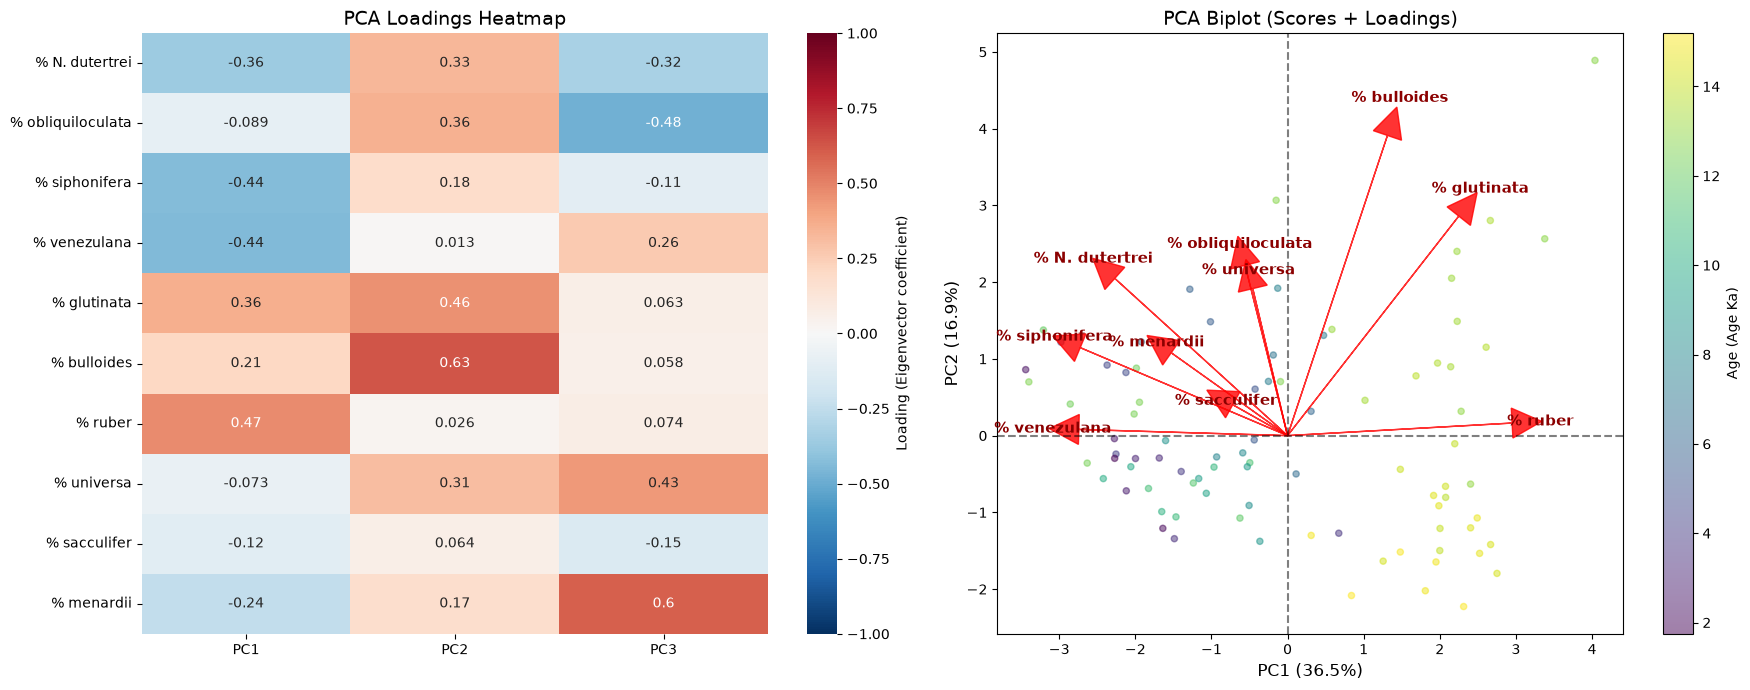

Loading 95% Confidence Intervals (from Bootstrapping):

PC1:
  % N. dutertrei      : -0.364  [-0.477, -0.205]
  % obliquiloculata   : -0.089  [-0.245,  0.071]
  % siphonifera       : -0.436  [-0.507, -0.316]
  % venezulana        : -0.439  [-0.507, -0.341]
  % glutinata         :  0.360  [ 0.212,  0.508]
  % bulloides         :  0.210  [ 0.024,  0.484]
  % ruber             :  0.473  [ 0.401,  0.512]
  % universa          : -0.073  [-0.262,  0.090]
  % sacculifer        : -0.115  [-0.269,  0.023]
  % menardii          : -0.245  [-0.414, -0.082]

PC2:
  % N. dutertrei      :  0.328  [-0.254,  0.494]
  % obliquiloculata   :  0.356  [-0.233,  0.724]
  % siphonifera       :  0.184  [-0.200,  0.349]
  % venezulana        :  0.013  [-0.305,  0.283]
  % glutinata         :  0.458  [-0.056,  0.540]
  % bulloides         :  0.627  [-0.008,  0.691]
  % ruber             :  0.026  [-0.182,  0.257]
  % universa          :  0.307  [-0.445,  0.785]
  % sacculifer        :  0.064  [-0.496,  0.578]
  

In [40]:
# LOADING HEATMAP & BIPLOT (do not edit)
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Loading Heatmap
sns.heatmap(loadings_df, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0],
            cbar_kws={'label': 'Loading (Eigenvector coefficient)'})
axes[0].set_title('PCA Loadings Heatmap', fontsize=14)

# 2. Biplot (PC1 vs PC2)
ax2 = axes[1]
ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c=pca_age, cmap='viridis', s=20)
cb = plt.colorbar(ax2.collections[0], ax=ax2)
cb.set_label(f'Age ({AGE_COLUMN})')

# Add variable vectors
scaling_factor = np.max(np.abs(X_pca[:, :2])) / np.max(np.abs(pca.components_[:2, :]))
for i, feature in enumerate(PROXY_COLUMNS):
    ax2.arrow(0, 0, pca.components_[0, i] * scaling_factor * 0.8, pca.components_[1, i] * scaling_factor * 0.8,
              color='red', alpha=0.8, head_width=0.05*scaling_factor, head_length=0.05*scaling_factor)
    ax2.text(pca.components_[0, i] * scaling_factor * 0.9, pca.components_[1, i] * scaling_factor * 0.9,
             feature, color='darkred', ha='center', va='center', fontsize=11, fontweight='bold')

ax2.set_xlabel(f'PC1 ({explained_variance[0]:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({explained_variance[1]:.1f}%)' if pca.n_components_ > 1 else 'PC2', fontsize=12)
ax2.set_title('PCA Biplot (Scores + Loadings)', fontsize=14)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.axvline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print Confidence Intervals
print("Loading 95% Confidence Intervals (from Bootstrapping):")
for c in range(pca.n_components_):
    print(f"\nPC{c+1}:")
    for i, proxy in enumerate(PROXY_COLUMNS):
        lower = np.percentile(loadings_boot[:, c, i], 2.5)
        upper = np.percentile(loadings_boot[:, c, i], 97.5)
        print(f"  {proxy:20s}: {pca.components_[c, i]:>6.3f}  [{lower:>6.3f}, {upper:>6.3f}]")

---
<a id='section-13'></a>
## Section 13: PC Score Time Series

This visualizes the extracted Principal Components over time. These time series represent the dominant, independent modes of variance in your multiproxy dataset.
- **PC1:** Often represents the global climate signal (e.g., glacial-interglacial cycles).
- **PC2/PC3:** Often represent secondary local effects (e.g., productivity, preservation, distinct ocean currents).

The results here can be exported to `REDFIT_WWZ_Reference.ipynb` for spectral analysis.

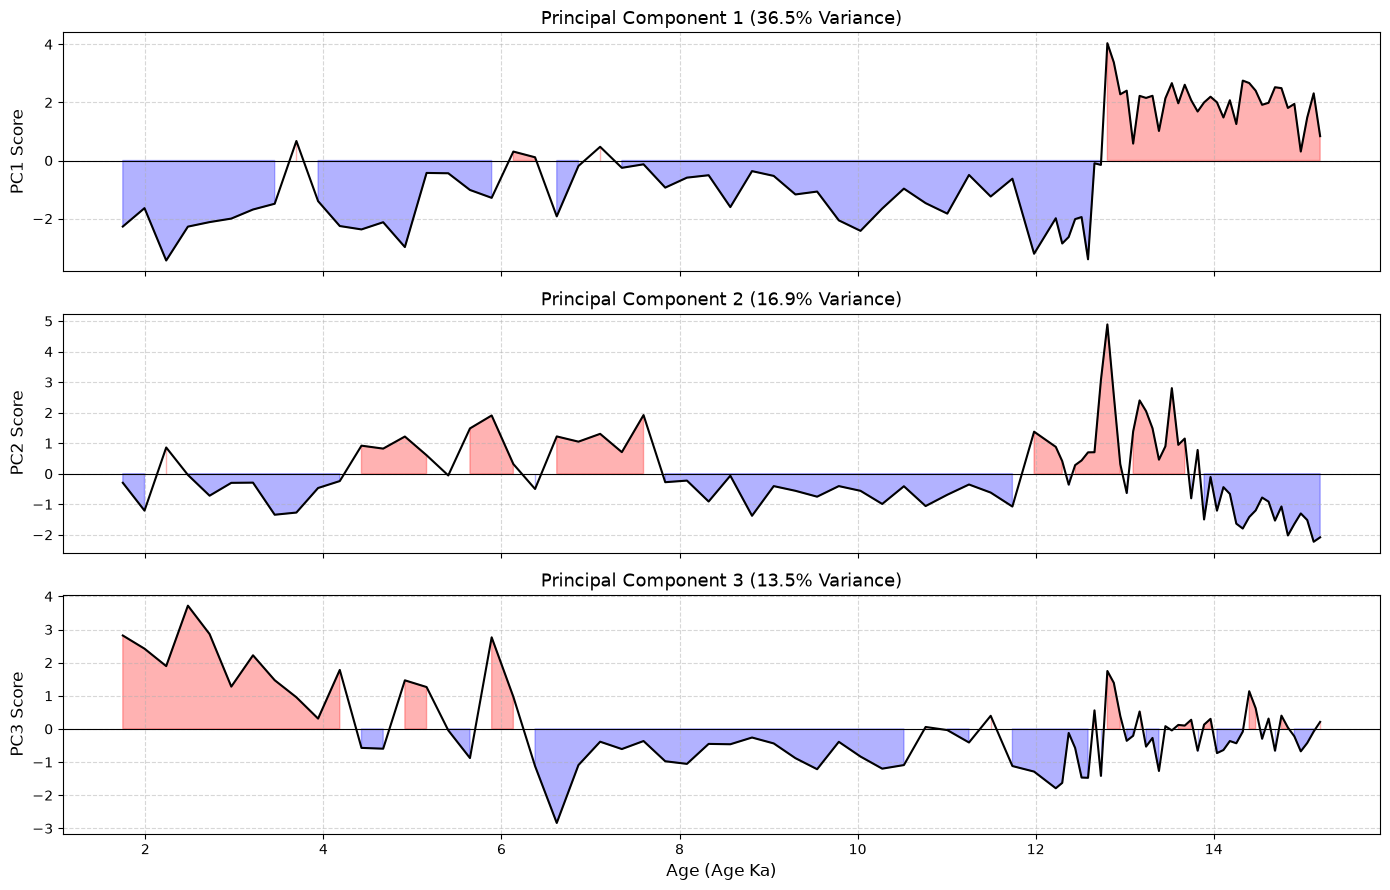


First 5 rows of PC Score Time Series:


,Age Ka,PC1,PC2,PC3
0,15.195001,0.839222,-2.083560,0.212265
1,15.122586,2.312731,-2.226936,-0.080328
2,15.050172,1.480807,-1.516688,-0.423645
3,14.977757,0.310098,-1.300355,-0.676409
4,14.905343,1.949736,-1.646318,-0.223053


In [41]:
# PC SCORE TIME SERIES (do not edit)
fig, axes = plt.subplots(pca.n_components_, 1, figsize=(14, 3 * pca.n_components_), sharex=True)
if pca.n_components_ == 1:
    axes = [axes]

for i in range(pca.n_components_):
    ax = axes[i]
    ax.plot(pca_age, X_pca[:, i], color='black', linewidth=1.5)
    
    # Optional shading for visual clarity
    ax.fill_between(pca_age, 0, X_pca[:, i], where=(X_pca[:, i] > 0), color='red', alpha=0.3)
    ax.fill_between(pca_age, 0, X_pca[:, i], where=(X_pca[:, i] <= 0), color='blue', alpha=0.3)
    
    ax.set_ylabel(f'PC{i+1} Score', fontsize=12)
    ax.set_title(f'Principal Component {i+1} ({explained_variance[i]:.1f}% Variance)', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)

axes[-1].set_xlabel(f'Age ({AGE_COLUMN})', fontsize=12)
if 'CLIMATE_BANDS' in globals():
    for ax in axes:
        for band in CLIMATE_BANDS:
            ax.axvspan(band[0], band[1], color=band[2], alpha=band[3], zorder=0)

plt.tight_layout()
plt.show()

# Build export dataframe
pc_export_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
pc_export_df.insert(0, AGE_COLUMN, pca_age.values)
print("\nFirst 5 rows of PC Score Time Series:")
display(pc_export_df.head())

---
<a id='section-14'></a>
## Section 14: Alternative Methods — Factor Analysis (FA)

**Factor Analysis** is similar to PCA but with a different core philosophy. While PCA simply rotates the data to maximize variance, FA assumes that there are hidden, unobservable "latent factors" driving the data, plus unique measurement noise for each proxy.

**Why use it?** If you believe your proxies have significant idiosyncratic noise (e.g. species-specific ecological artifacts) and you only want to extract the shared underlying climate signal.

--- EXECUTING FACTOR ANALYSIS ---


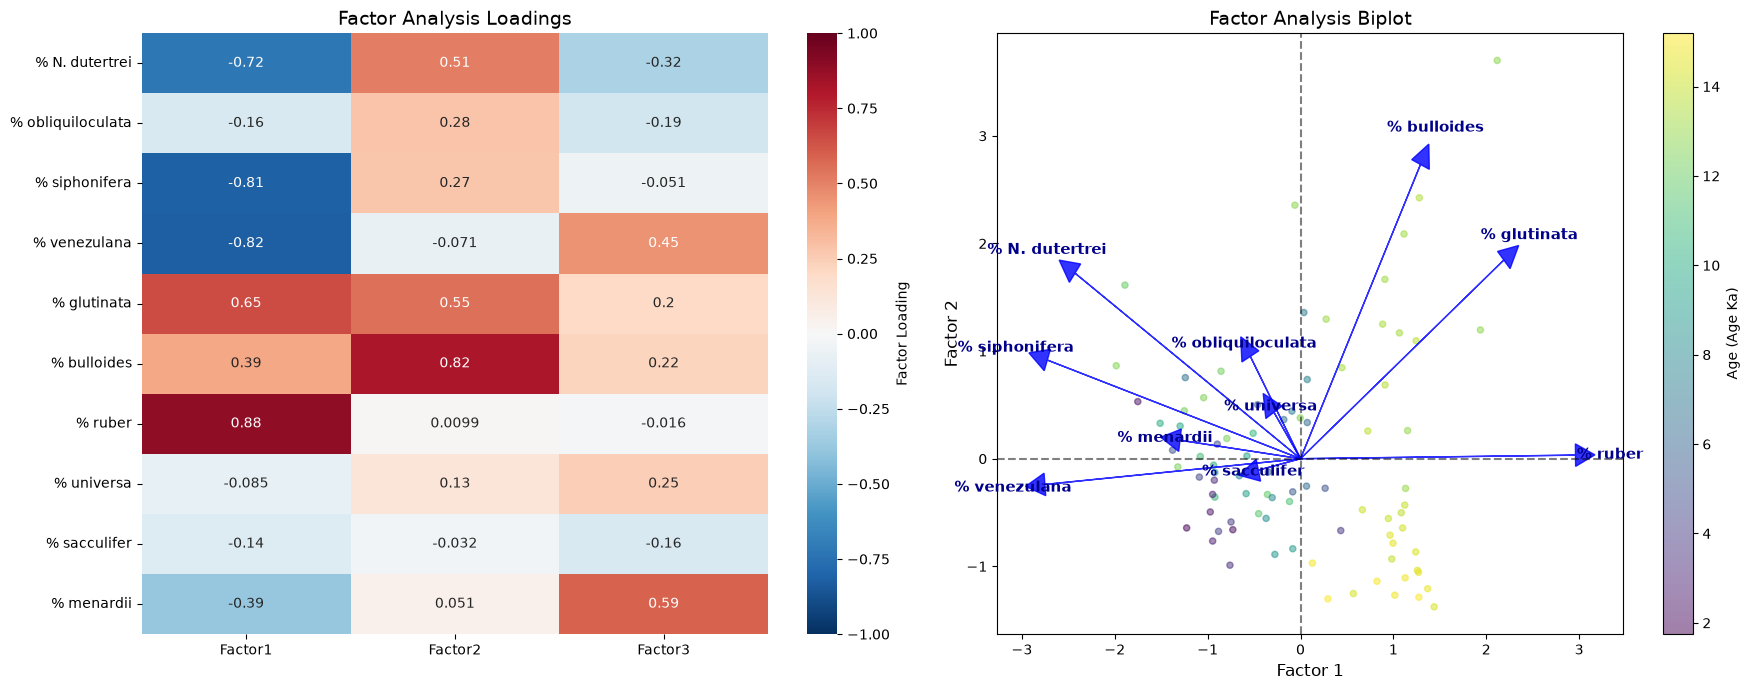

In [42]:
# FACTOR ANALYSIS (do not edit)
from sklearn.decomposition import FactorAnalysis

print("--- EXECUTING FACTOR ANALYSIS ---")
# Using the same X_scaled and pca_age as before
fa = FactorAnalysis(n_components=pca.n_components_, random_state=42)
X_fa = fa.fit_transform(X_scaled)

fa_loadings = pd.DataFrame(fa.components_.T, index=PROXY_COLUMNS, columns=[f'Factor{i+1}' for i in range(fa.n_components)])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. FA Loading Heatmap
import seaborn as sns
sns.heatmap(fa_loadings, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0],
            cbar_kws={'label': 'Factor Loading'})
axes[0].set_title('Factor Analysis Loadings', fontsize=14)

# 2. FA Biplot
ax2 = axes[1]
ax2.scatter(X_fa[:, 0], X_fa[:, 1], alpha=0.5, c=pca_age, cmap='viridis', s=20)
cb = plt.colorbar(ax2.collections[0], ax=ax2)
cb.set_label(f'Age ({AGE_COLUMN})')

scaling_factor_fa = np.max(np.abs(X_fa[:, :2])) / np.max(np.abs(fa.components_[:2, :]))
for i, feature in enumerate(PROXY_COLUMNS):
    ax2.arrow(0, 0, fa.components_[0, i] * scaling_factor_fa * 0.8, fa.components_[1, i] * scaling_factor_fa * 0.8,
              color='blue', alpha=0.8, head_width=0.05*scaling_factor_fa, head_length=0.05*scaling_factor_fa)
    ax2.text(fa.components_[0, i] * scaling_factor_fa * 0.9, fa.components_[1, i] * scaling_factor_fa * 0.9,
             feature, color='darkblue', ha='center', va='center', fontsize=11, fontweight='bold')

ax2.set_xlabel('Factor 1', fontsize=12)
ax2.set_ylabel('Factor 2' if fa.n_components > 1 else '', fontsize=12)
ax2.set_title('Factor Analysis Biplot', fontsize=14)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.axvline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
<a id='section-15'></a>
## Section 15: Alternative Methods — Independent Component Analysis (ICA)

**Independent Component Analysis (ICA)** searches for components that are not just uncorrelated (like PCA), but *statistically independent*. It attempts to maximize the non-Gaussianity of the components.

**Why use it?** It is excellent for "blind source separation"—for example, separating a distinct orbital forcing signal from an independent high-frequency ENSO or monsoonal signal. 
*Note:* ICA components are not strictly ordered by variance, unlike PCA.

--- EXECUTING INDEPENDENT COMPONENT ANALYSIS ---


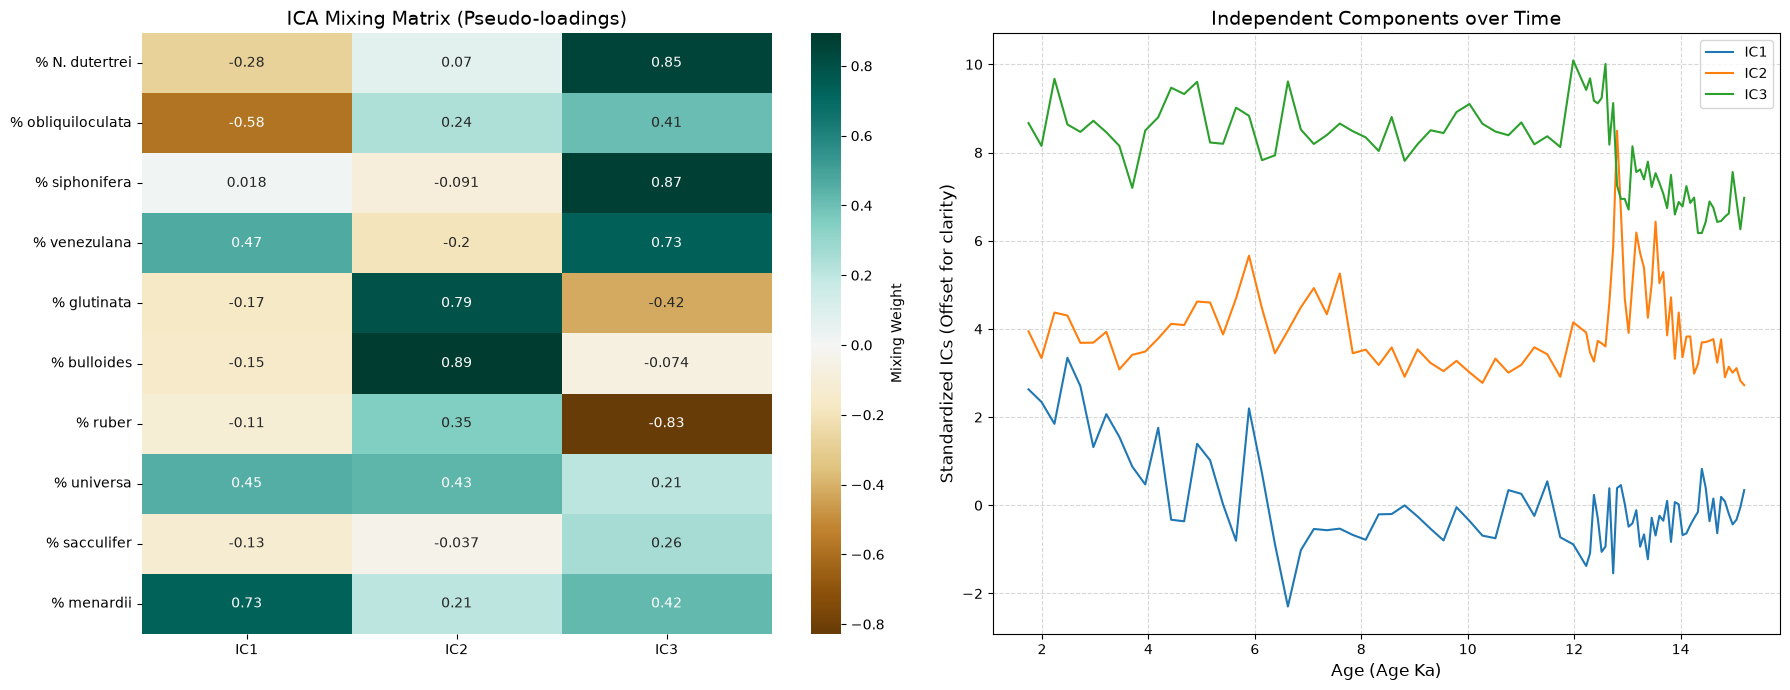

In [43]:
# INDEPENDENT COMPONENT ANALYSIS (do not edit)
from sklearn.decomposition import FastICA
import warnings
warnings.filterwarnings('ignore', category=UserWarning) # ignore fastica convergence warnings on small datasets

print("--- EXECUTING INDEPENDENT COMPONENT ANALYSIS ---")
ica = FastICA(n_components=pca.n_components_, random_state=42)
X_ica = ica.fit_transform(X_scaled)

ica_mixing = pd.DataFrame(ica.mixing_, index=PROXY_COLUMNS, columns=[f'IC{i+1}' for i in range(ica.n_components)])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. ICA Mixing Heatmap
sns.heatmap(ica_mixing, annot=True, cmap='BrBG', center=0, ax=axes[0],
            cbar_kws={'label': 'Mixing Weight'})
axes[0].set_title('ICA Mixing Matrix (Pseudo-loadings)', fontsize=14)

# 2. ICA Time Series
ax2 = axes[1]
for i in range(ica.n_components):
    # Standardize the ICs for visual comparison
    ic_std = (X_ica[:, i] - np.mean(X_ica[:, i])) / np.std(X_ica[:, i])
    ax2.plot(pca_age, ic_std + (i * 4), label=f'IC{i+1}', linewidth=1.5)

ax2.set_xlabel(f'Age ({AGE_COLUMN})', fontsize=12)
ax2.set_ylabel('Standardized ICs (Offset for clarity)', fontsize=12)
ax2.set_title('Independent Components over Time', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
<a id='section-16'></a>
## Section 16: Alternative Methods — UMAP (Visualization)

**UMAP (Uniform Manifold Approximation and Projection)** is a state-of-the-art non-linear dimensionality reduction technique.

**Why use it?** While PCA assumes linear relationships, paleoclimate state-spaces are often highly non-linear. UMAP preserves both local and global structure to provide a brilliant 2D map of the climate state-space. It can visually reveal distinct clustering (e.g., distinct Holocene states vs. LGM states) that linear PCA might blur.
*Note: UMAP axes have no direct physical units. This is strictly for visualization.*

--- EXECUTING UMAP ---


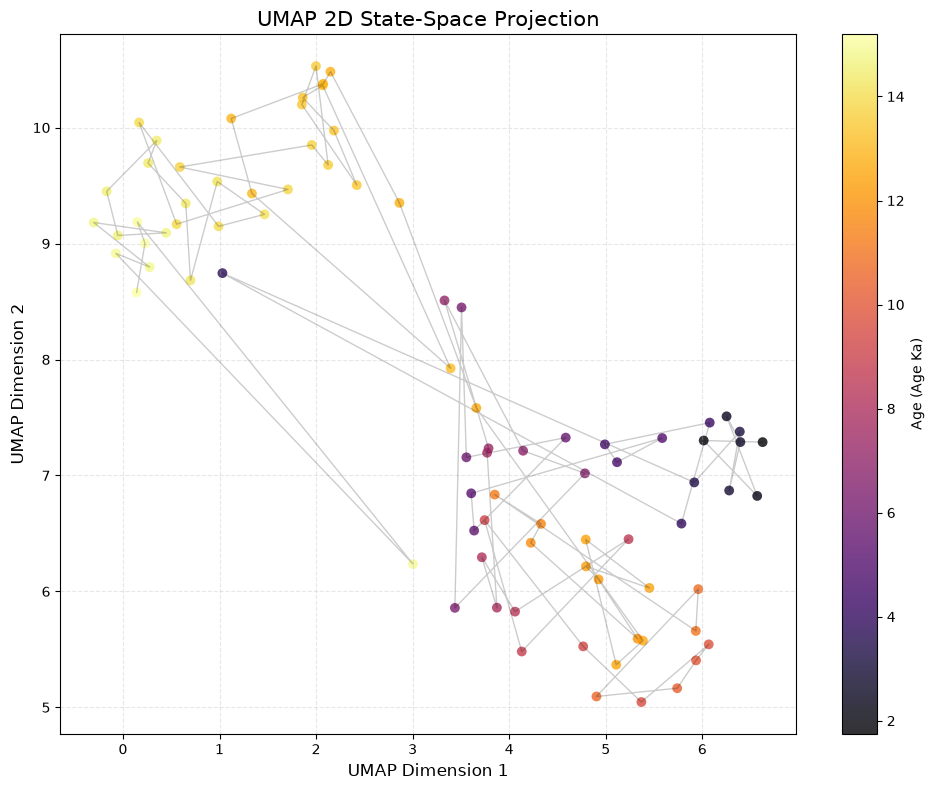

In [47]:
# UMAP VISUALIZATION (do not edit)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP is not installed. To run this block, install it via: pip install umap-learn")

if UMAP_AVAILABLE:
    print("--- EXECUTING UMAP ---")
    reducer = umap.UMAP(n_neighbors=min(15, pca_data.shape[0]-1), min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=pca_age, cmap='inferno', s=50, alpha=0.8, edgecolors='none')
    
    # Add a path to show time evolution
    ax.plot(embedding[:, 0], embedding[:, 1], 'k-', alpha=0.2, linewidth=1)
    
    cb = plt.colorbar(scatter)
    cb.set_label(f'Age ({AGE_COLUMN})')
    
    ax.set_title('UMAP 2D State-Space Projection', fontsize=15)
    ax.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax.set_ylabel('UMAP Dimension 2', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

---
<a id='section-17'></a>
## Section 17: Interpretation Guide & Next Steps

**How to interpret your results:**
1. **Scree Plot & Parallel Analysis:** Look at Section 11. If your PC crosses the red dotted line (Parallel Analysis 95% CI), it contains statistically significant variance above random noise. You should usually drop PCs that fall below this line.
2. **PC1 vs. PC2:** Does PC1 correlate strongly with known global forcings (e.g. ice volume, insolation)? PC1 is usually the dominant climatic mode.
3. **FA vs. ICA:** If your PCA loadings are difficult to interpret physically, compare them to the ICA and FA results. ICA might isolate a specific physical process into a single component.

**Next Steps (Spectral Analysis):**
The ultimate goal of this notebook is to extract a clean signal for spectral analysis to search for Milankovitch cycles. Run the export block below to save your Principal Components, and then open the `REDFIT_WWZ_Reference.ipynb` notebook and set its data input to the newly generated `PC_scores.csv` file.

In [45]:
# EXPORT PC SCORES FOR REDFIT ANALYSIS (do not edit)
import os

export_filename = 'PC_scores.csv'
pc_export_df.to_csv(export_filename, index=False)

print("="*60)
print(f"SUCCESS: Your data has been saved to '{export_filename}'.")
print("="*60)
print("You can now use this file directly as the DATA_FILE input in your REDFIT_WWZ_Reference.ipynb notebook.")
print("The columns available for spectral analysis are:")
print(list(pc_export_df.columns))

SUCCESS: Your data has been saved to 'PC_scores.csv'.
You can now use this file directly as the DATA_FILE input in your REDFIT_WWZ_Reference.ipynb notebook.
The columns available for spectral analysis are:
['Age Ka', 'PC1', 'PC2', 'PC3']


In [46]:
# REPRODUCIBILITY LOG (do not edit)
import json
import datetime
import sys
import sklearn

log_data = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "notebook": "TimeSeries_PCA_Reference.ipynb",
    "python_version": sys.version,
    "sklearn_version": sklearn.__version__,
    "parameters": {
        "N_COMPONENTS": N_COMPONENTS,
        "STANDARDIZE": STANDARDIZE,
        "N_BOOTSTRAP": N_BOOTSTRAP
    },
    "data_shape": pca_data.shape,
    "proxies_used": list(PROXY_COLUMNS),
    "variance_explained": list(np.round(explained_variance, 2))
}

with open("Reproducibility_Log_PCA.json", "w") as f:
    json.dump(log_data, f, indent=4)
    
print("Reproducibility log saved to 'Reproducibility_Log_PCA.json'")

Reproducibility log saved to 'Reproducibility_Log_PCA.json'
